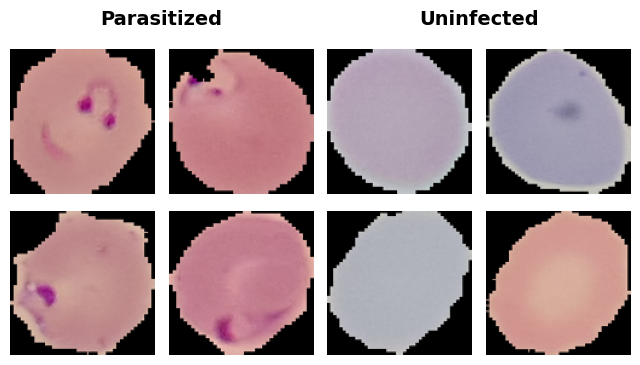

In [7]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Caminhos das pastas
infected_dir = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Parasitized'
uninfected_dir = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Uninfected'

# Seleciona 4 imagens aleatórias de cada classe
infected_samples = random.sample(os.listdir(infected_dir), 4)
uninfected_samples = random.sample(os.listdir(uninfected_dir), 4)

# Tamanho fixo para padronizar as imagens
img_size = (120, 120)

# Cria figura e grade
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
plt.subplots_adjust(wspace=0.1, hspace=0.1)

# Plota parasitadas (colunas 0 e 1)
for i in range(2):
    for j in range(2):
        idx = i * 2 + j
        img = Image.open(os.path.join(infected_dir, infected_samples[idx])).resize(img_size)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        axes[i, j].set_aspect('equal')

# Plota não infectadas (colunas 2 e 3)
for i in range(2):
    for j in range(2, 4):
        idx = i * 2 + (j - 2)
        img = Image.open(os.path.join(uninfected_dir, uninfected_samples[idx])).resize(img_size)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        axes[i, j].set_aspect('equal')

# -------- Centralização precisa com bbox --------
# Pega posição média dos dois primeiros eixos (colunas 0 e 1)
bbox1 = axes[0, 0].get_position()
bbox2 = axes[0, 1].get_position()
center1 = (bbox1.x0 + bbox2.x1) / 2

# Pega posição média dos dois últimos eixos (colunas 2 e 3)
bbox3 = axes[0, 2].get_position()
bbox4 = axes[0, 3].get_position()
center2 = (bbox3.x0 + bbox4.x1) / 2

# Adiciona os textos exatamente no centro visual
fig.text(center1, 0.94, 'Parasitized', ha='center', fontsize=14, weight='bold')
fig.text(center2, 0.94, 'Uninfected', ha='center', fontsize=14, weight='bold')

plt.show()

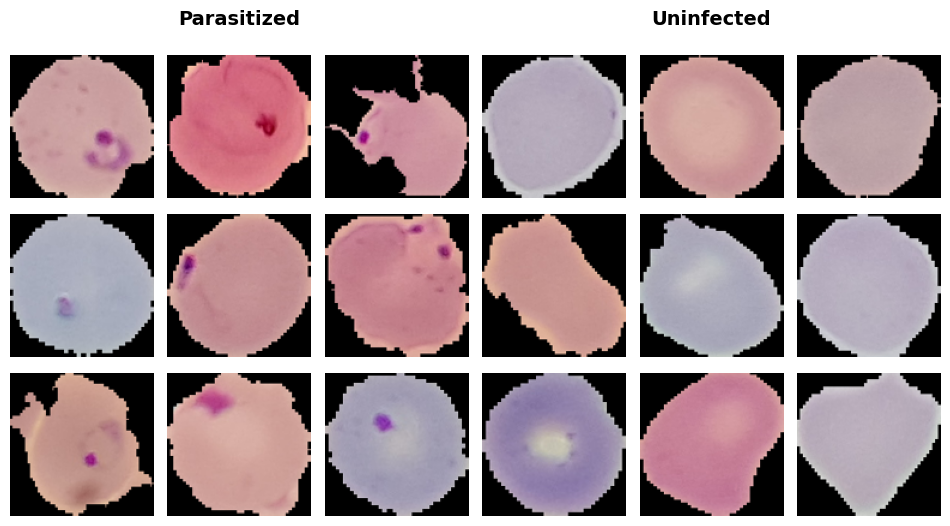

In [10]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Caminhos das pastas
infected_dir = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Parasitized'
uninfected_dir = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Uninfected'

# Seleciona 9 imagens aleatórias de cada classe
infected_samples = random.sample(os.listdir(infected_dir), 9)
uninfected_samples = random.sample(os.listdir(uninfected_dir), 9)

# Tamanho fixo
img_size = (120, 120)

# Cria figura 3x6
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
plt.subplots_adjust(wspace=0.1, hspace=0.1)

# Parasitized: colunas 0 a 2
for i in range(3):
    for j in range(3):
        idx = i * 3 + j
        img = Image.open(os.path.join(infected_dir, infected_samples[idx])).resize(img_size)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        axes[i, j].set_aspect('equal')

# Uninfected: colunas 3 a 5
for i in range(3):
    for j in range(3, 6):
        idx = i * 3 + (j - 3)
        img = Image.open(os.path.join(uninfected_dir, uninfected_samples[idx])).resize(img_size)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        axes[i, j].set_aspect('equal')

# Centraliza os títulos
bbox1 = axes[0, 0].get_position()
bbox2 = axes[0, 2].get_position()
center1 = (bbox1.x0 + bbox2.x1) / 2

bbox3 = axes[0, 3].get_position()
bbox4 = axes[0, 5].get_position()
center2 = (bbox3.x0 + bbox4.x1) / 2

fig.text(center1, 0.93, 'Parasitized', ha='center', fontsize=14, weight='bold')
fig.text(center2, 0.93, 'Uninfected', ha='center', fontsize=14, weight='bold')

plt.show()



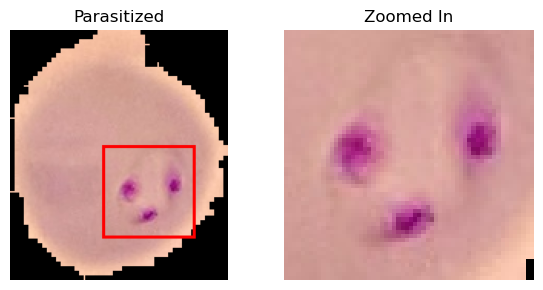

In [15]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Caminho da imagem
img_path = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Parasitized\C33P1thinF_IMG_20150619_114756a_cell_179.png'
img = Image.open(img_path)

# NOVAS coordenadas ajustadas
x_min, y_min = 60, 75
x_max, y_max = x_min + 60, y_min + 60

# Faz o crop
cropped = img.crop((x_min, y_min, x_max, y_max))

# Desenha o retângulo
img_with_box = img.copy()
draw = ImageDraw.Draw(img_with_box)
draw.rectangle([(x_min, y_min), (x_max, y_max)], outline="red", width=2)

# Exibe lado a lado
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(img_with_box)
plt.title('Parasitized')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cropped)
plt.title('Zoomed In')
plt.axis('off')

plt.tight_layout()
plt.show()



In [18]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def plot_color_histogram(img_path, title):
    img = Image.open(img_path).resize((120, 120))
    img_np = np.array(img)

    # Remove pixels pretos do fundo
    mask = ~(np.all(img_np == [0, 0, 0], axis=-1))
    img_np = img_np[mask]

    plt.figure(figsize=(10, 5))  # gráfico maior
    for i, color in enumerate(['Red', 'Green', 'Blue']):
        plt.hist(img_np[:, i], bins=256, color=color.lower(), alpha=0.8, label=color)

    plt.title(f'Histograma de Cores - {title}', fontsize=14)
    plt.xlabel('Intensidade', fontsize=12)
    plt.ylabel('Frequência', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()


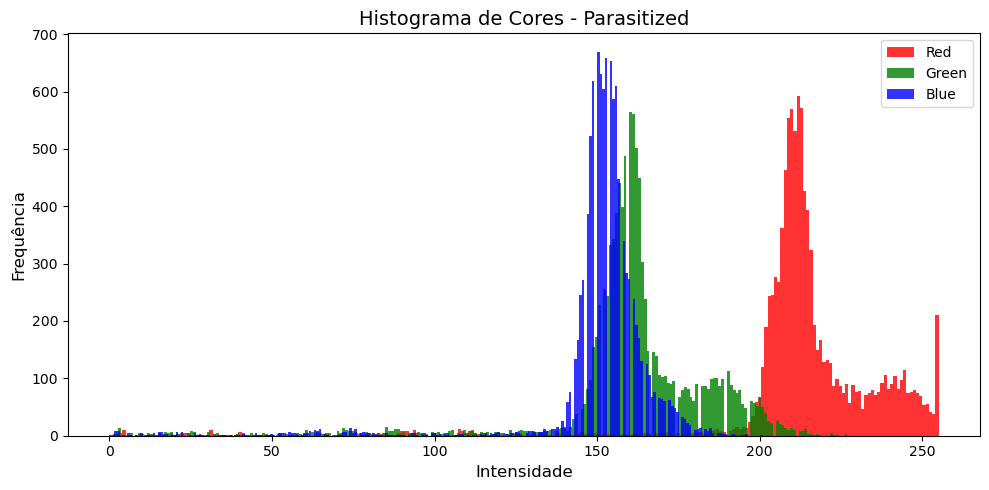

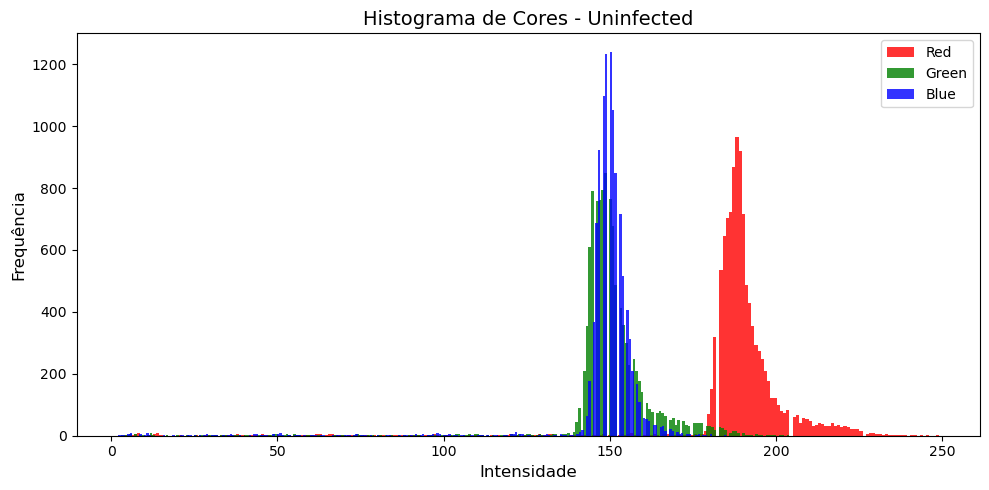

In [19]:
img_path1 = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Parasitized\C33P1thinF_IMG_20150619_114756a_cell_179.png'
img_path2 = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Uninfected\C1_thinF_IMG_20150604_104722_cell_9.png'

plot_color_histogram(img_path1, 'Parasitized')
plot_color_histogram(img_path2, 'Uninfected')


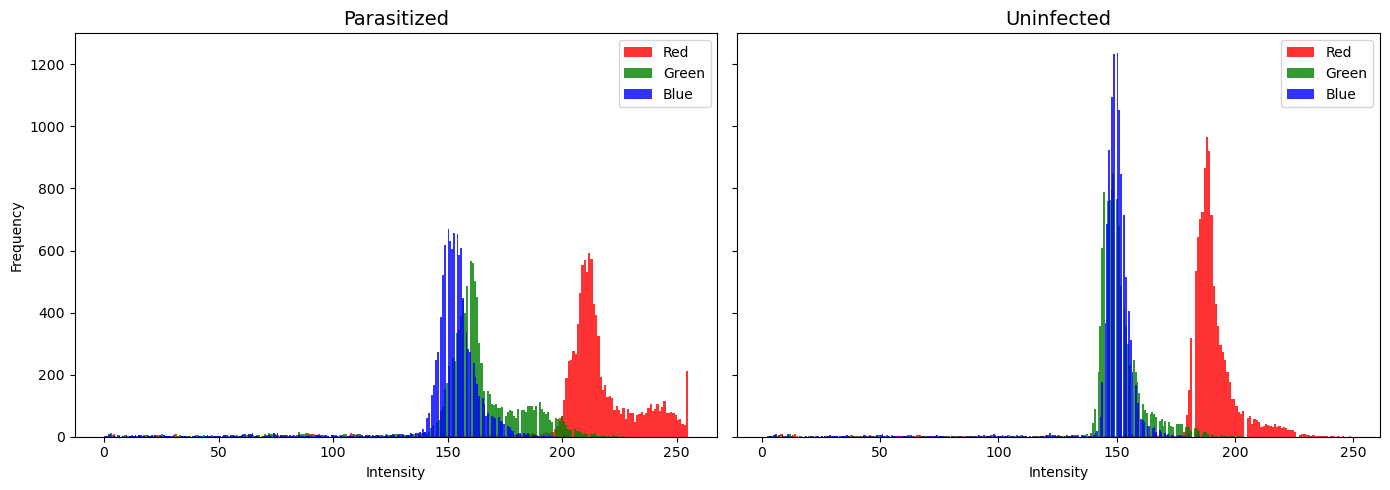

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def get_histogram_data(img_path):
    img = Image.open(img_path).resize((120, 120))
    img_np = np.array(img)

    # Remove fundo preto
    mask = ~(np.all(img_np == [0, 0, 0], axis=-1))
    img_np = img_np[mask]

    # Separa os canais
    r = img_np[:, 0]
    g = img_np[:, 1]
    b = img_np[:, 2]

    return r, g, b

# Caminhos das imagens
path_parasitized = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Parasitized\C33P1thinF_IMG_20150619_114756a_cell_179.png'
path_uninfected = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Uninfected\C1_thinF_IMG_20150604_104722_cell_9.png'
# Coleta os dados
r_p, g_p, b_p = get_histogram_data(path_parasitized)
r_u, g_u, b_u = get_histogram_data(path_uninfected)

# Cria figura lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Parasitized
axes[0].hist(r_p, bins=256, color='red', alpha=0.8, label='Red')
axes[0].hist(g_p, bins=256, color='green', alpha=0.8, label='Green')
axes[0].hist(b_p, bins=256, color='blue', alpha=0.8, label='Blue')
axes[0].set_title('Parasitized', fontsize=14)
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Uninfected
axes[1].hist(r_u, bins=256, color='red', alpha=0.8, label='Red')
axes[1].hist(g_u, bins=256, color='green', alpha=0.8, label='Green')
axes[1].hist(b_u, bins=256, color='blue', alpha=0.8, label='Blue')
axes[1].set_title('Uninfected', fontsize=14)
axes[1].set_xlabel('Intensity')
axes[1].legend()

plt.tight_layout()
plt.show()


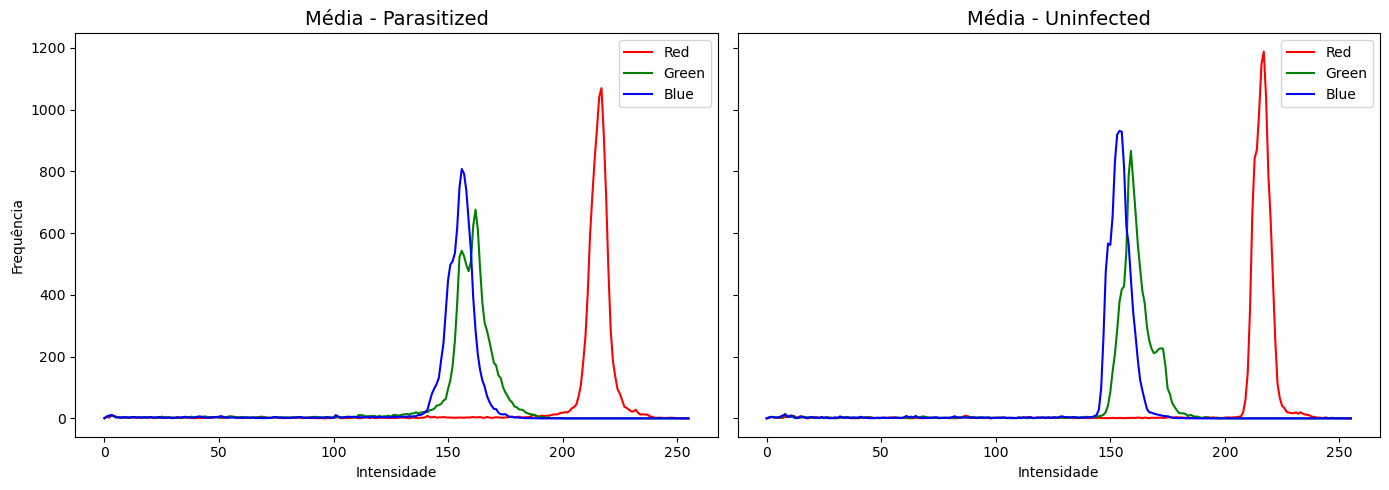

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def get_histogram_from_image(img_path):
    img = Image.open(img_path).resize((120, 120))
    img_np = np.array(img)

    # Remove pixels pretos do fundo
    mask = ~(np.all(img_np == [0, 0, 0], axis=-1))
    img_np = img_np[mask]

    # Canais separados
    r = img_np[:, 0]
    g = img_np[:, 1]
    b = img_np[:, 2]

    # Calcula histograma para cada canal
    r_hist, _ = np.histogram(r, bins=256, range=(0, 255))
    g_hist, _ = np.histogram(g, bins=256, range=(0, 255))
    b_hist, _ = np.histogram(b, bins=256, range=(0, 255))

    return r_hist, g_hist, b_hist

# Diretórios
infected_dir = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Parasitized'
uninfected_dir = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Uninfected'

# Seleciona 5 imagens de cada
infected_imgs = [os.path.join(infected_dir, f) for f in sorted(os.listdir(infected_dir)) if f.endswith('.png')][:5]
uninfected_imgs = [os.path.join(uninfected_dir, f) for f in sorted(os.listdir(uninfected_dir)) if f.endswith('.png')][:5]

# Inicializa acumuladores
r_p_total = np.zeros(256)
g_p_total = np.zeros(256)
b_p_total = np.zeros(256)

r_u_total = np.zeros(256)
g_u_total = np.zeros(256)
b_u_total = np.zeros(256)

# Acumula histogramas
for img_path in infected_imgs:
    r, g, b = get_histogram_from_image(img_path)
    r_p_total += r
    g_p_total += g
    b_p_total += b

for img_path in uninfected_imgs:
    r, g, b = get_histogram_from_image(img_path)
    r_u_total += r
    g_u_total += g
    b_u_total += b

# Média
r_p_avg = r_p_total / len(infected_imgs)
g_p_avg = g_p_total / len(infected_imgs)
b_p_avg = b_p_total / len(infected_imgs)

r_u_avg = r_u_total / len(uninfected_imgs)
g_u_avg = g_u_total / len(uninfected_imgs)
b_u_avg = b_u_total / len(uninfected_imgs)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Parasitized
axes[0].plot(r_p_avg, color='red', label='Red')
axes[0].plot(g_p_avg, color='green', label='Green')
axes[0].plot(b_p_avg, color='blue', label='Blue')
axes[0].set_title('Média - Parasitized', fontsize=14)
axes[0].set_xlabel('Intensidade')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Uninfected
axes[1].plot(r_u_avg, color='red', label='Red')
axes[1].plot(g_u_avg, color='green', label='Green')
axes[1].plot(b_u_avg, color='blue', label='Blue')
axes[1].set_title('Média - Uninfected', fontsize=14)
axes[1].set_xlabel('Intensidade')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def get_histogram_data(img_path):
    img = Image.open(img_path).resize((120, 120))
    img_np = np.array(img)

    # Remove fundo preto
    mask = ~(np.all(img_np == [0, 0, 0], axis=-1))
    img_np = img_np[mask]

    # Separa os canais
    r = img_np[:, 0]
    g = img_np[:, 1]
    b = img_np[:, 2]

    return r, g, b

# Caminhos das imagens
path_parasitized = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Parasitized\C33P1thinF_IMG_20150619_114756a_cell_179.png'
path_uninfected = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\cell_images\Uninfected\C1_thinF_IMG_20150604_104722_cell_9.png'
# Coleta os dados
r_p, g_p, b_p = get_histogram_data(path_parasitized)
r_u, g_u, b_u = get_histogram_data(path_uninfected)

# Cria figura lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Parasitized
axes[0].hist(r_p, bins=256, color='red', alpha=0.8, label='Red')
axes[0].hist(g_p, bins=256, color='green', alpha=0.8, label='Green')
axes[0].hist(b_p, bins=256, color='blue', alpha=0.8, label='Blue')
axes[0].set_title('Parasitized', fontsize=14)
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Uninfected
axes[1].hist(r_u, bins=256, color='red', alpha=0.8, label='Red')
axes[1].hist(g_u, bins=256, color='green', alpha=0.8, label='Green')
axes[1].hist(b_u, bins=256, color='blue', alpha=0.8, label='Blue')
axes[1].set_title('Uninfected', fontsize=14)
axes[1].set_xlabel('Intensity')
axes[1].legend()

plt.tight_layout()
plt.show()


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Carregando os dados
df_swin = pd.read_csv(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\swin-variations\swin-sem-optuna\kfold_epoch_results.csv")
df_resnet = pd.read_csv(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\resnet\normal\kfold_epoch_results.csv")

df_optuna_swin = df_swin.iloc[102:].reset_index(drop=True)
df_swin = df_swin.iloc[:100].reset_index(drop=True)

# Identificar a rede
df_swin["network"] = "SwinTransformer"
df_resnet["network"] = "ResNet50"
df_optuna_swin["network"] = "SwinTransformerOptuna"

# Unir os dados
df_all = pd.concat([df_swin, df_resnet], ignore_index=True)


In [2]:
df_swin.tail()

,fold,epoch,model,loss,accuracy,precision,recall,f1_score,true_positives,false_positives,true_negatives,false_negatives,learning_rate,network
95,5,16,SwinTransformer_Fold5,0.003790,97.210252,0.979282,0.964626,0.971899,2127,45,2159,78,0.00001,SwinTransformer
96,5,17,SwinTransformer_Fold5,0.002773,97.119528,0.979686,0.962358,0.970945,2122,44,2160,83,0.00001,SwinTransformer
97,5,18,SwinTransformer_Fold5,0.002893,97.119528,0.983256,0.958730,0.970838,2114,36,2168,91,0.00001,SwinTransformer
98,5,19,SwinTransformer_Fold5,0.001191,97.187571,0.977075,0.966440,0.971728,2131,50,2154,74,0.00001,SwinTransformer
99,5,20,SwinTransformer_Fold5,0.001471,97.255614,0.974499,0.970522,0.972506,2140,56,2148,65,0.00001,SwinTransformer


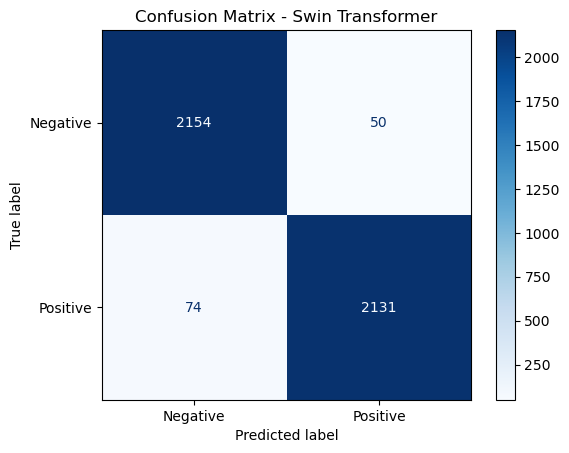

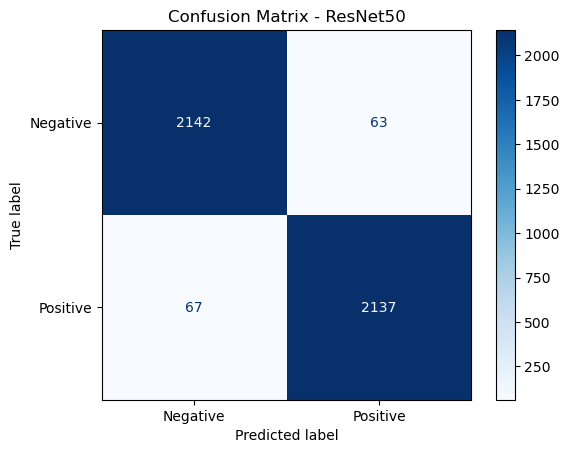

In [3]:
def plot_confusion_from_counts(tp, fp, tn, fn, model_name):
    y_true = [1]*tp + [0]*tn + [1]*fn + [0]*fp
    y_pred = [1]*tp + [0]*tn + [0]*fn + [1]*fp
    cm = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
    disp.plot(cmap="Blues", values_format='d')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.grid(False)
    plt.show()

# Melhor modelo Swin
best_swin = df_swin.loc[df_swin['loss'].idxmin()]
plot_confusion_from_counts(
    int(best_swin['true_positives']),
    int(best_swin['false_positives']),
    int(best_swin['true_negatives']),
    int(best_swin['false_negatives']),
    "Swin Transformer"
)

# Melhor modelo ResNet
best_resnet = df_resnet.loc[df_resnet['loss'].idxmin()]
plot_confusion_from_counts(
    int(best_resnet['true_positives']),
    int(best_resnet['false_positives']),
    int(best_resnet['true_negatives']),
    int(best_resnet['false_negatives']),
    "ResNet50"
)


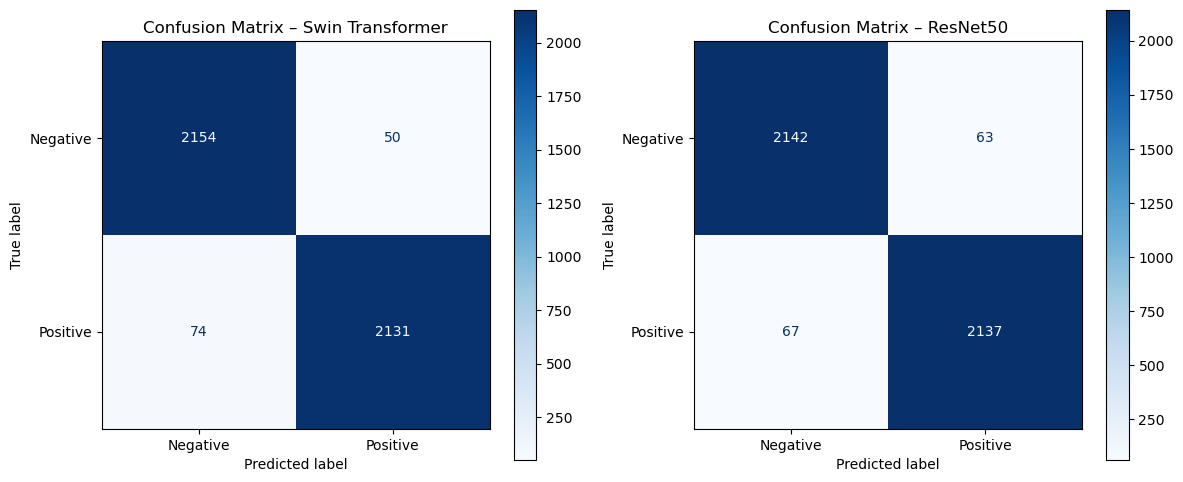

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Dados do melhor modelo Swin
best_swin = df_swin.loc[df_swin['loss'].idxmin()]
cm_swin = confusion_matrix(
    [1]*int(best_swin['true_positives']) + [1]*int(best_swin['false_negatives']) +
    [0]*int(best_swin['true_negatives']) + [0]*int(best_swin['false_positives']),
    
    [1]*int(best_swin['true_positives']) + [0]*int(best_swin['false_negatives']) +
    [0]*int(best_swin['true_negatives']) + [1]*int(best_swin['false_positives'])
)

# Dados do melhor modelo ResNet
best_resnet = df_resnet.loc[df_resnet['loss'].idxmin()]
cm_resnet = confusion_matrix(
    [1]*int(best_resnet['true_positives']) + [1]*int(best_resnet['false_negatives']) +
    [0]*int(best_resnet['true_negatives']) + [0]*int(best_resnet['false_positives']),
    
    [1]*int(best_resnet['true_positives']) + [0]*int(best_resnet['false_negatives']) +
    [0]*int(best_resnet['true_negatives']) + [1]*int(best_resnet['false_positives'])
)

# Plot lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Swin
disp_swin = ConfusionMatrixDisplay(cm_swin, display_labels=["Negative", "Positive"])
disp_swin.plot(ax=axes[0], cmap="Blues", values_format='d')
axes[0].set_title("Confusion Matrix – Swin Transformer")

# ResNet
disp_resnet = ConfusionMatrixDisplay(cm_resnet, display_labels=["Negative", "Positive"])
disp_resnet.plot(ax=axes[1], cmap="Blues", values_format='d')
axes[1].set_title("Confusion Matrix – ResNet50")

# Remover títulos automáticos duplicados nos eixos
for ax in axes:
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()


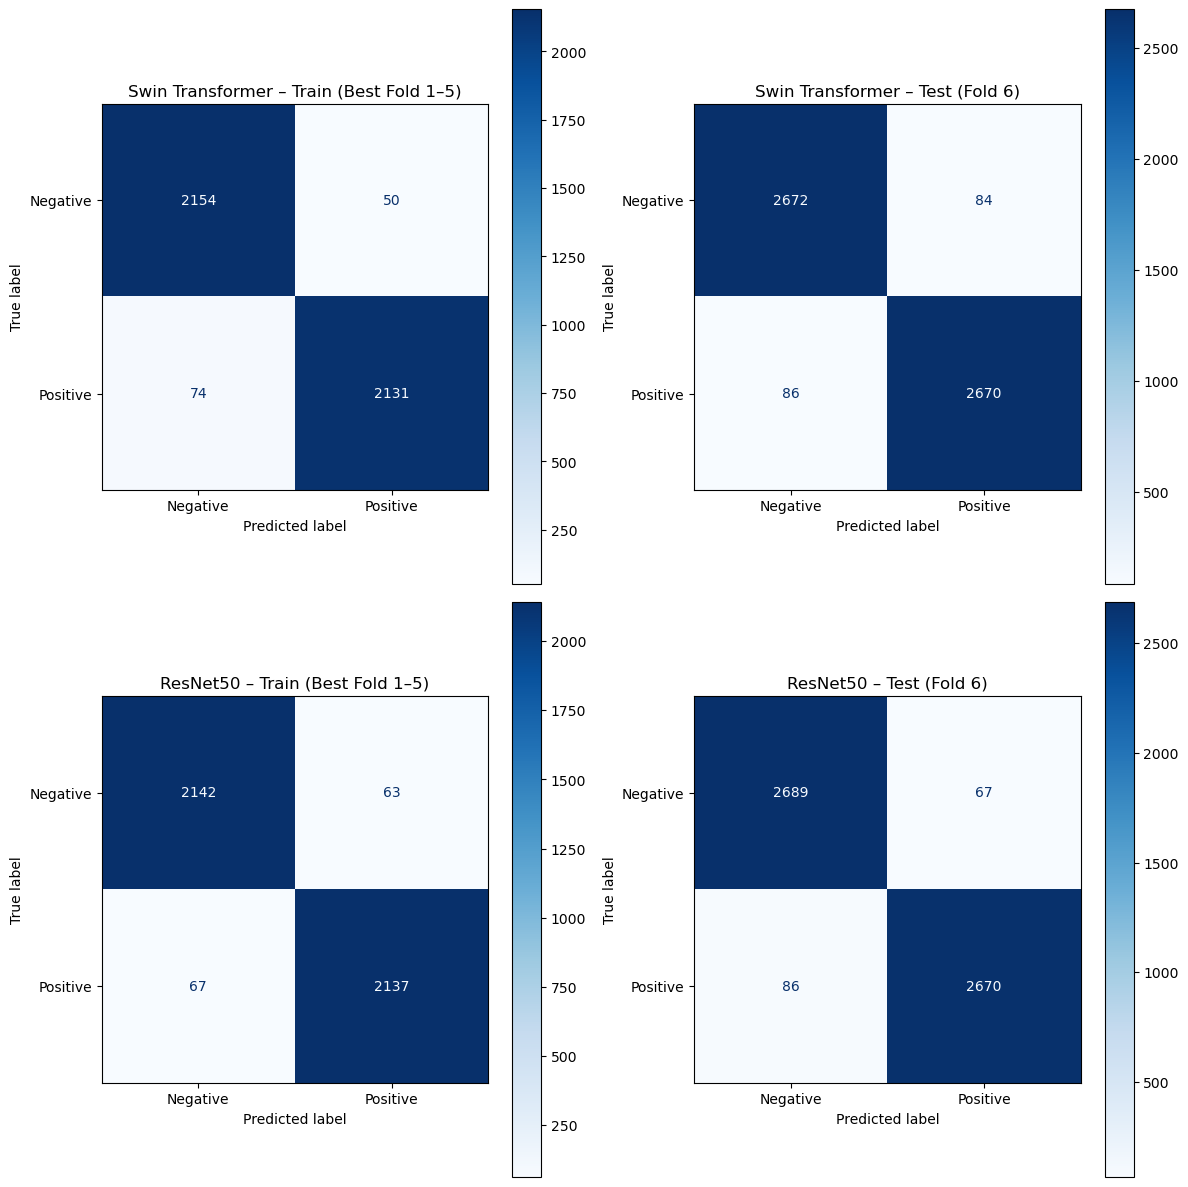

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Função para construir y_true e y_pred a partir das contagens
def construir_arrays_confusao(tp, fp, tn, fn):
    y_true = [1]*tp + [1]*fn + [0]*tn + [0]*fp
    y_pred = [1]*tp + [0]*fn + [0]*tn + [1]*fp
    return y_true, y_pred

# Carregar os dados dos CSVs
df_swin = pd.read_csv(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\swin-variations\swin-sem-optuna\kfold_epoch_results.csv")
df_resnet = pd.read_csv(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\resnet\normal\kfold_epoch_results.csv")

# Filtrar os folds 1 a 5 para encontrar o modelo com menor loss
df_swin_train = df_swin[df_swin['fold'].isin([1, 2, 3, 4, 5])]
df_resnet_train = df_resnet[df_resnet['fold'].isin([1, 2, 3, 4, 5])]

# Selecionar o modelo com menor loss para Swin Transformer e ResNet50
melhor_swin = df_swin_train.loc[df_swin_train['loss'].idxmin()]
melhor_resnet = df_resnet_train.loc[df_resnet_train['loss'].idxmin()]

# Selecionar os dados do fold 6 para Swin Transformer e ResNet50
swin_fold6 = df_swin[df_swin['fold'] == 6].iloc[0]
resnet_fold6 = df_resnet[df_resnet['fold'] == 6].iloc[0]

# Criar subplots 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Plotar as matrizes de confusão
for ax, modelo, dados, titulo in zip(axes.flatten(),
                                     ['Swin Transformer', 'Swin Transformer', 'ResNet50', 'ResNet50'],
                                     [melhor_swin, swin_fold6, melhor_resnet, resnet_fold6],
                                     ['Train (Best Fold 1–5)', 'Test (Fold 6)', 'Train (Best Fold 1–5)', 'Test (Fold 6)']):
    y_true, y_pred = construir_arrays_confusao(int(dados['true_positives']),
                                               int(dados['false_positives']),
                                               int(dados['true_negatives']),
                                               int(dados['false_negatives']))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax, cmap="Blues", values_format='d')
    ax.set_title(f"{modelo} – {titulo}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()


C:\Users\sthem\AppData\Local\Temp\ipykernel_36916\3445276029.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 0.96])


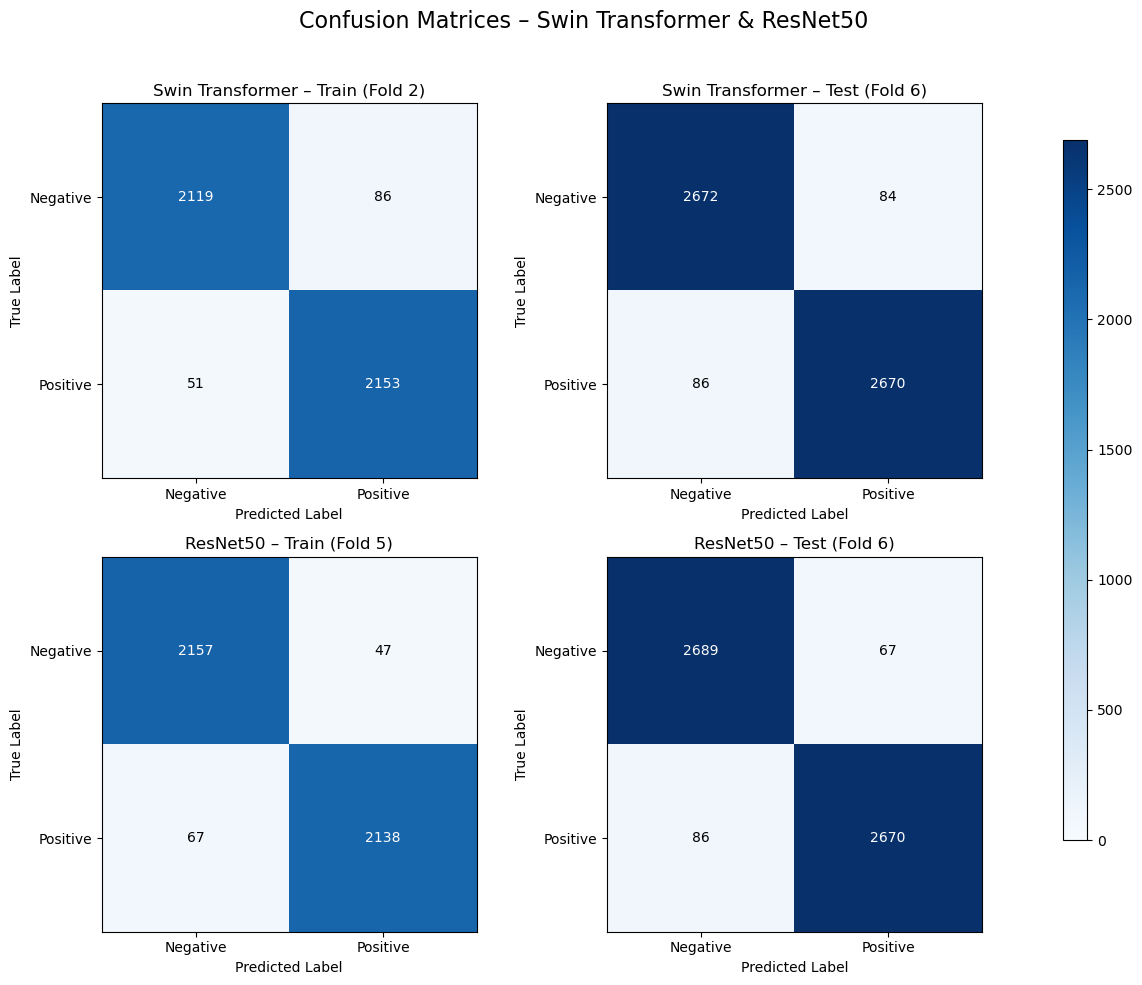

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Caminhos dos arquivos
df_swin = pd.read_csv(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\swin-variations\swin-sem-optuna\kfold_epoch_results.csv")
df_resnet = pd.read_csv(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\resnet\normal\kfold_epoch_results.csv")

# Função para reconstruir y_true e y_pred
def construir_arrays_confusao(tp, fp, tn, fn):
    y_true = [1]*tp + [1]*fn + [0]*tn + [0]*fp
    y_pred = [1]*tp + [0]*fn + [0]*tn + [1]*fp
    return y_true, y_pred

# Selecionar modelos
#swin_train = df_swin[df_swin['fold'].isin([1, 2, 3, 4, 5])].loc[df_swin[df_swin['fold'].isin([1, 2, 3, 4, 5])]['loss'].idxmin()]
#resnet_train = df_resnet[df_resnet['fold'].isin([1, 2, 3, 4, 5])].loc[df_resnet[df_resnet['fold'].isin([1, 2, 3, 4, 5])]['loss'].idxmin()]
swin_train = df_swin[df_swin['fold'] == 2].iloc[0]
resnet_train = df_resnet[df_resnet['fold'] == 5].iloc[0]
swin_test = df_swin[df_swin['fold'] == 6].iloc[0]
resnet_test = df_resnet[df_resnet['fold'] == 6].iloc[0]

# Montar modelos e títulos
#modelos = [
    #("Swin Transformer – Train (Best Fold 1–5)", swin_train),
    #("Swin Transformer – Test (Fold 6)", swin_test),
    #("ResNet50 – Train (Best Fold 1–5)", resnet_train),
    #("ResNet50 – Test (Fold 6)", resnet_test),
#]

modelos = [
    ("Swin Transformer – Train (Fold 2)", swin_train),
    ("Swin Transformer – Test (Fold 6)", swin_test),
    ("ResNet50 – Train (Fold 5)", resnet_train),
    ("ResNet50 – Test (Fold 6)", resnet_test),
]


# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cmaps = []
vmax = 0  # para normalizar todas as matrizes com mesma escala

# Primeiro, calcular os valores e encontrar o valor máximo
cms = []
for _, row in modelos:
    y_true, y_pred = construir_arrays_confusao(
        int(row['true_positives']),
        int(row['false_positives']),
        int(row['true_negatives']),
        int(row['false_negatives'])
    )
    cm = confusion_matrix(y_true, y_pred)
    cms.append(cm)
    vmax = max(vmax, cm.max())

# Agora, desenhar cada matriz
for ax, (title, _), cm in zip(axes.flatten(), modelos, cms):
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Negative", "Positive"])
    ax.set_yticklabels(["Negative", "Positive"])
    
    # Mostrar valores dentro da matriz
    thresh = vmax / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

# Adicionar uma única colorbar à direita
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)

plt.suptitle("Confusion Matrices – Swin Transformer & ResNet50", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.88, 0.96])
plt.show()



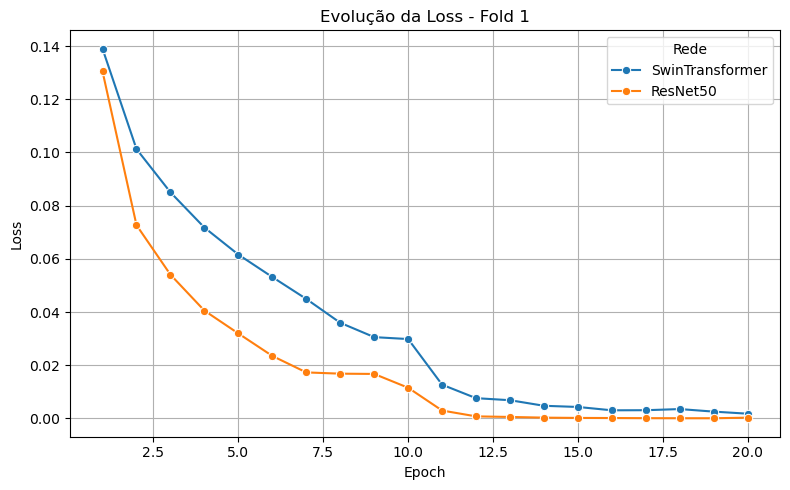

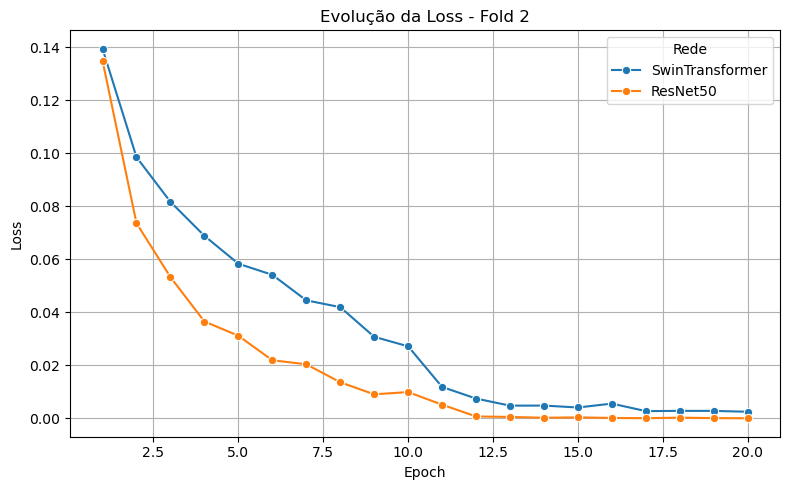

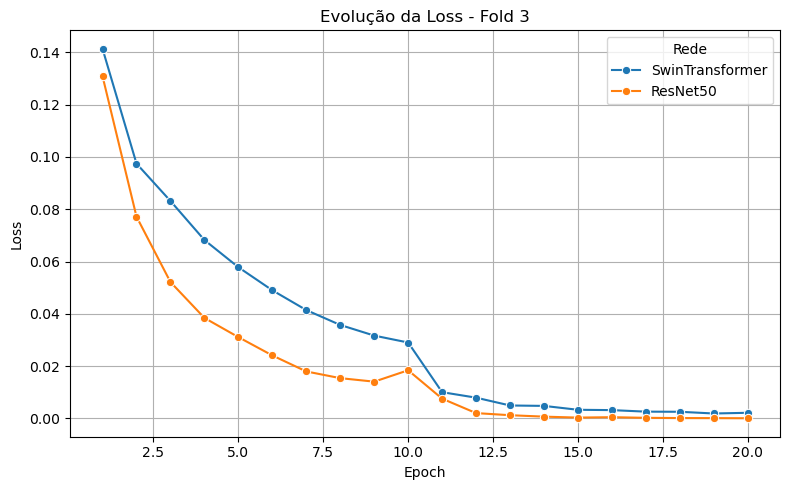

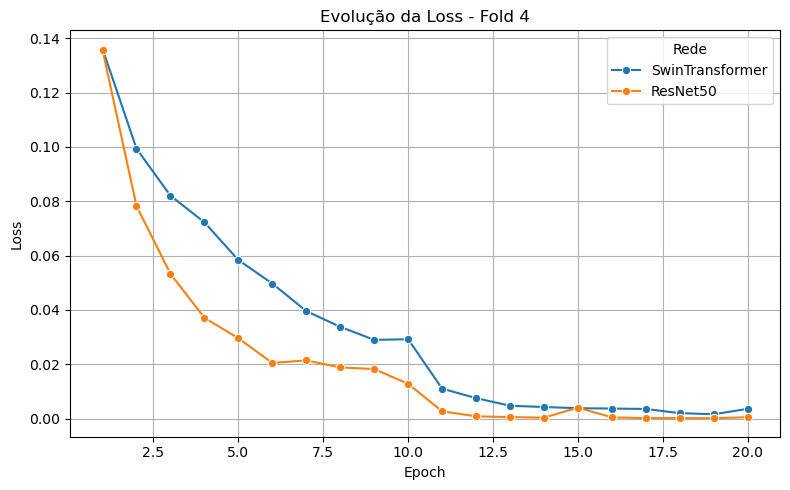

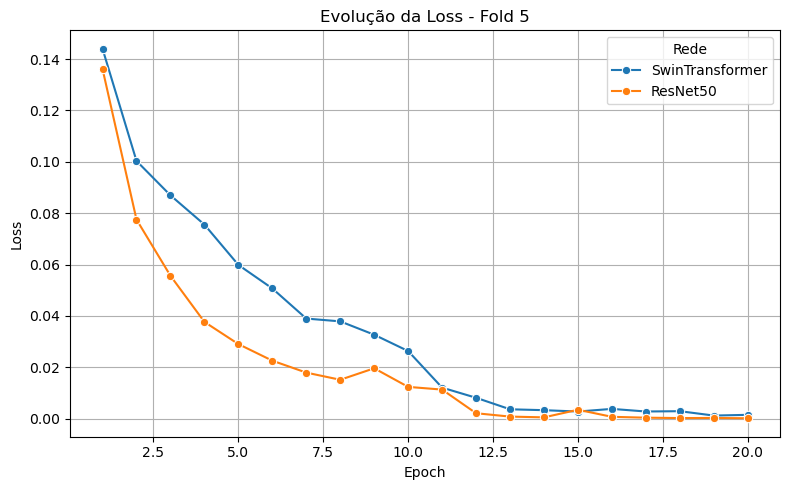

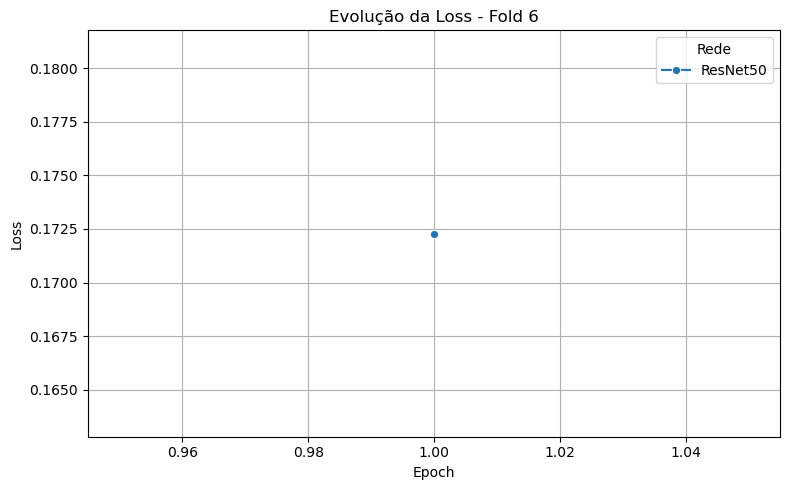

In [7]:
# Gráfico de evolução da loss por epoch, separado por fold
for fold in sorted(df_all['fold'].unique()):
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=df_all[df_all['fold'] == fold], x='epoch', y='loss', hue='network', marker="o")
    plt.title(f"Evolução da Loss - Fold {fold}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend(title="Rede")
    plt.tight_layout()
    plt.show()


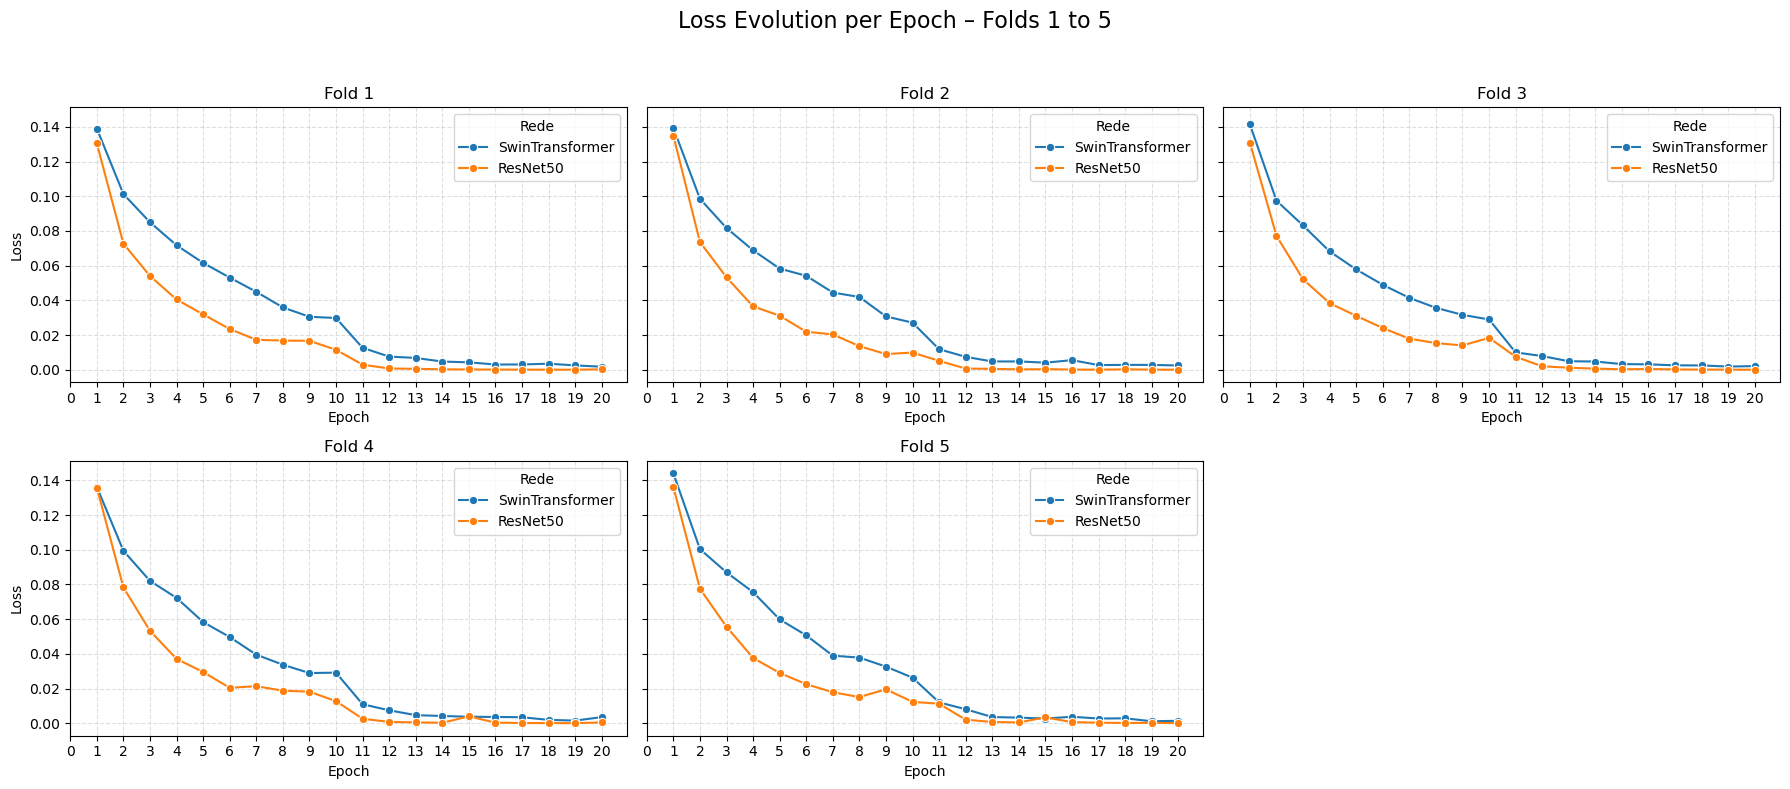

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remover fold 6
df_filt = df_all[df_all['fold'] != 6]

# Folds restantes
folds = sorted(df_filt['fold'].unique())  # [1, 2, 3, 4, 5]

# Criar subplots em grid 2x3 (6 slots, o último ficará vazio)
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
axes = axes.flatten()

# Plotar um gráfico por fold
for i, fold in enumerate(folds):
    ax = axes[i]
    sns.lineplot(
        data=df_filt[df_filt['fold'] == fold],
        x='epoch',
        y='loss',
        hue='network',
        marker='o',
        ax=ax
    )
    ax.set_title(f"Fold {fold}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_xticks(range(0, 21))
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(title='Rede', loc='best')

# Ocultar o último subplot vazio (posição 6)
axes[-1].axis('off')

# Título geral e layout ajustado
plt.suptitle("Loss Evolution per Epoch – Folds 1 to 5", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


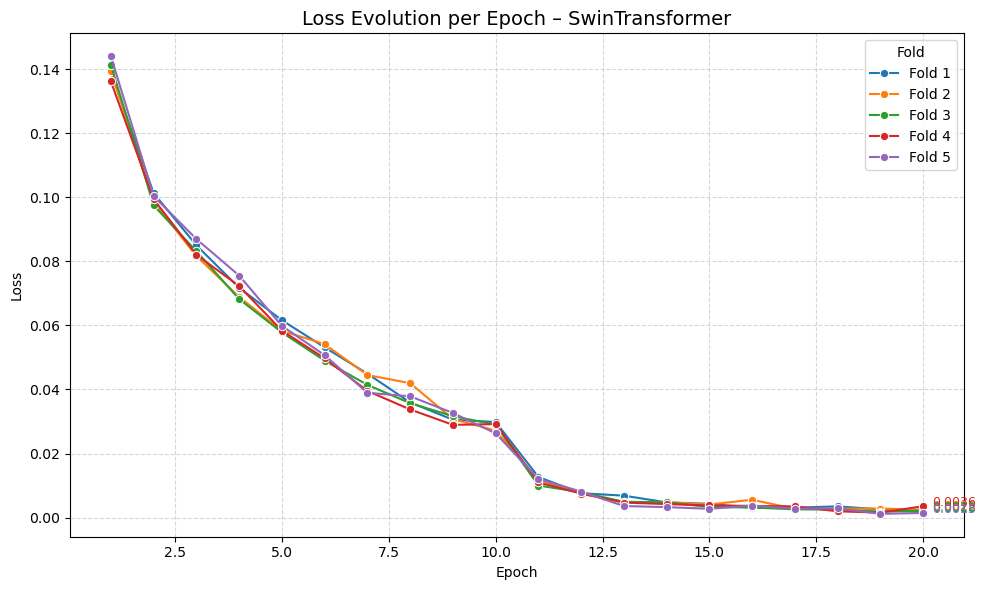

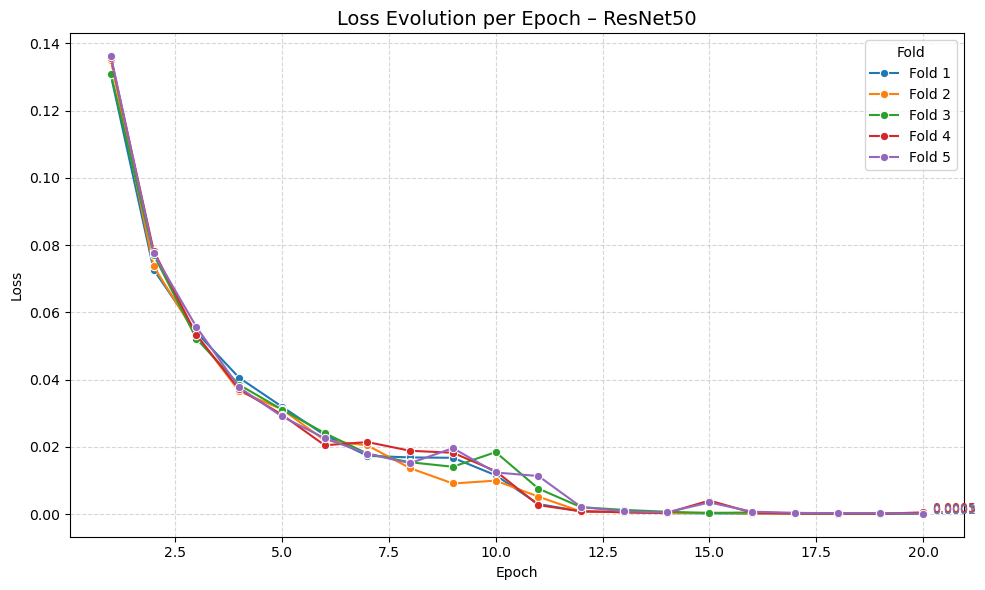

In [9]:
# Paleta fixa para até 5 folds (reutilizando a anterior)
cores_folds = sns.color_palette("tab10", 5)

# Remover fold 6 (se necessário)
df_filtered = df_all[df_all['fold'] != 6]

# Gerar gráfico para cada rede
for rede in df_filtered['network'].unique():
    plt.figure(figsize=(10, 6))
    
    # Dados da rede específica
    df_rede = df_filtered[df_filtered['network'] == rede]

    # Traçar linhas por fold
    for i, fold in enumerate(sorted(df_rede['fold'].unique())):
        df_fold = df_rede[df_rede['fold'] == fold]
        sns.lineplot(
            data=df_fold,
            x='epoch',
            y='loss',
            label=f"Fold {fold}",
            color=cores_folds[i],
            marker='o'
        )
        
        # Adicionar valor final da loss no fim da curva
        last_point = df_fold[df_fold['epoch'] == df_fold['epoch'].max()]
        loss_final = last_point['loss'].values[0]
        epoch_final = last_point['epoch'].values[0]
        plt.text(epoch_final + 0.2, loss_final, f"{loss_final:.4f}", fontsize=9, color=cores_folds[i])

    plt.title(f"Loss Evolution per Epoch – {rede}", fontsize=14)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title="Fold", loc='upper right')
    plt.tight_layout()
    plt.show()


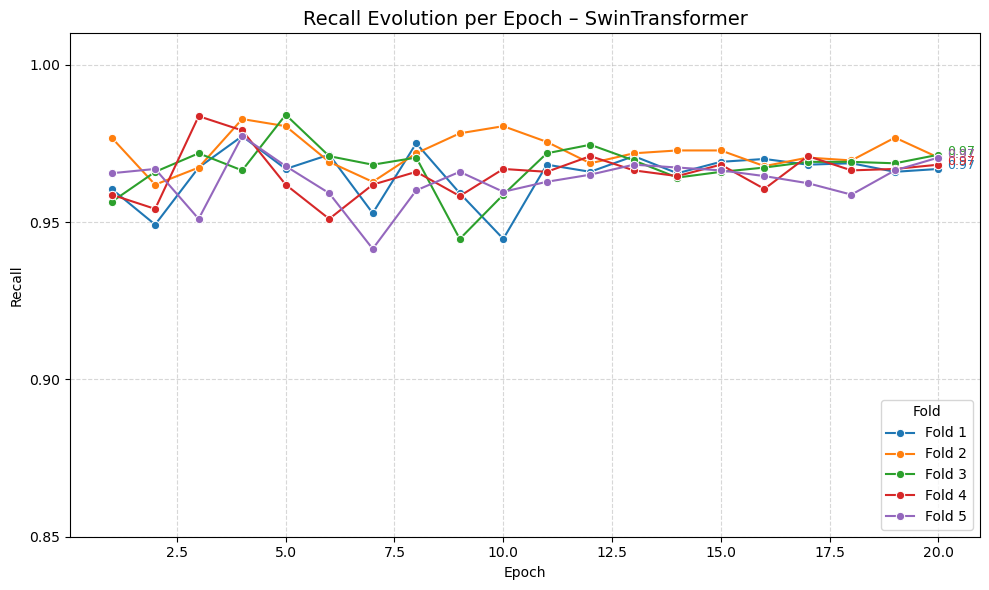

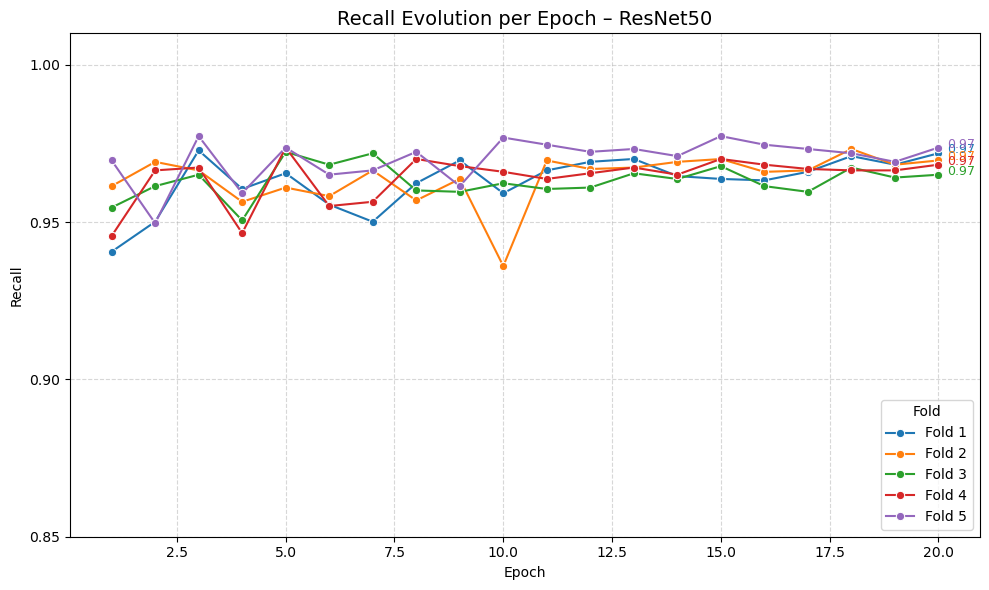

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Paleta fixa para até 5 folds
cores_folds = sns.color_palette("tab10", 5)

# Remover fold 6
df_filtered = df_all[df_all['fold'] != 6]

# Gerar gráfico para cada rede
for rede in df_filtered['network'].unique():
    plt.figure(figsize=(10, 6))
    
    # Dados da rede específica
    df_rede = df_filtered[df_filtered['network'] == rede]

    # Traçar linhas por fold
    for i, fold in enumerate(sorted(df_rede['fold'].unique())):
        df_fold = df_rede[df_rede['fold'] == fold]
        sns.lineplot(
            data=df_fold,
            x='epoch',
            y='recall',
            label=f"Fold {fold}",
            color=cores_folds[i],
            marker='o'
        )
        
        # Adicionar valor final do recall ao final da curva
        last_point = df_fold[df_fold['epoch'] == df_fold['epoch'].max()]
        recall_final = last_point['recall'].values[0]
        epoch_final = last_point['epoch'].values[0]
        plt.text(epoch_final + 0.2, recall_final, f"{recall_final:.2f}", fontsize=9, color=cores_folds[i])

    plt.title(f"Recall Evolution per Epoch – {rede}", fontsize=14)
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.ylim(0.85, 1.01)
    plt.yticks([0.85, 0.90, 0.95, 1.00])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title="Fold", loc='lower right')
    plt.tight_layout()
    plt.show()


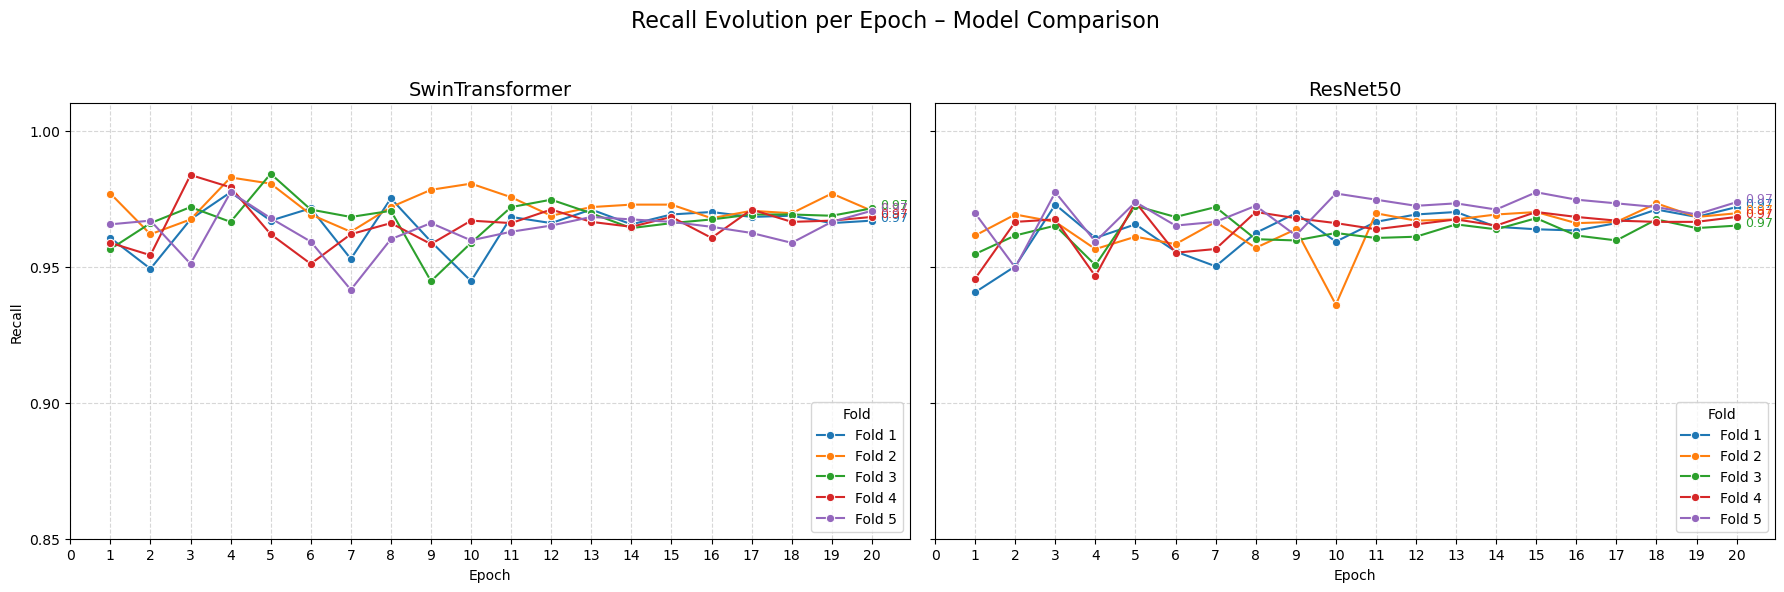

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Paleta fixa para até 5 folds
cores_folds = sns.color_palette("tab10", 5)

# Remover fold 6
df_filtered = df_all[df_all['fold'] != 6]

# Criar figura com 2 subplots (um para cada rede)
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Loop pelas redes
for idx, rede in enumerate(df_filtered['network'].unique()):
    ax = axes[idx]
    df_rede = df_filtered[df_filtered['network'] == rede]

    # Traçar linhas por fold
    for i, fold in enumerate(sorted(df_rede['fold'].unique())):
        df_fold = df_rede[df_rede['fold'] == fold]
        sns.lineplot(
            data=df_fold,
            x='epoch',
            y='recall',
            label=f"Fold {fold}",
            color=cores_folds[i],
            marker='o',
            ax=ax
        )
        
        # Adicionar valor final ao final da curva
        last_point = df_fold[df_fold['epoch'] == df_fold['epoch'].max()]
        recall_final = last_point['recall'].values[0]
        epoch_final = last_point['epoch'].values[0]
        ax.text(epoch_final + 0.2, recall_final, f"{recall_final:.2f}", fontsize=9, color=cores_folds[i])

    ax.set_title(f"{rede}", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Recall")
    ax.set_ylim(0.85, 1.01)
    ax.set_xticks(range(0, 21))  # <- eixo X com ticks de 0 a 20
    ax.set_yticks([0.85, 0.90, 0.95, 1.00])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Fold", loc='lower right')

# Título geral
plt.suptitle("Recall Evolution per Epoch – Model Comparison", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


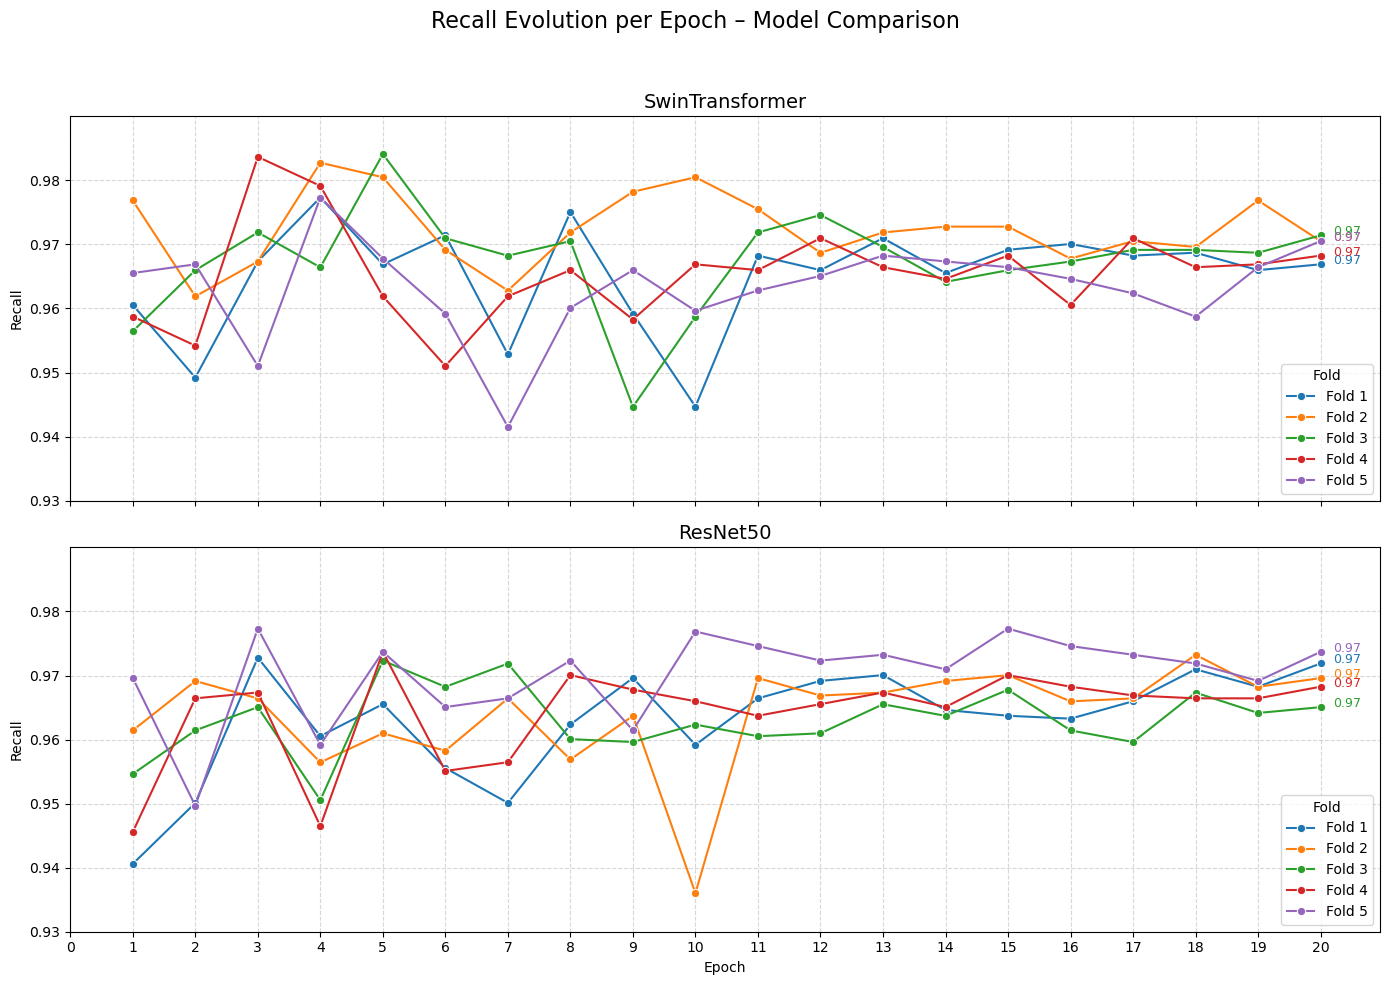

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Paleta fixa para até 5 folds
cores_folds = sns.color_palette("tab10", 5)

# Remover fold 6
df_filtered = df_all[df_all['fold'] != 6]

# Criar figura com 2 subplots (um em cima do outro)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)

# Loop pelas redes
for idx, rede in enumerate(df_filtered['network'].unique()):
    ax = axes[idx]
    df_rede = df_filtered[df_filtered['network'] == rede]

    # Traçar linhas por fold
    for i, fold in enumerate(sorted(df_rede['fold'].unique())):
        df_fold = df_rede[df_rede['fold'] == fold]
        sns.lineplot(
            data=df_fold,
            x='epoch',
            y='recall',
            label=f"Fold {fold}",
            color=cores_folds[i],
            marker='o',
            ax=ax
        )
        
        # Adicionar valor final ao final da curva
        last_point = df_fold[df_fold['epoch'] == df_fold['epoch'].max()]
        recall_final = last_point['recall'].values[0]
        epoch_final = last_point['epoch'].values[0]
        ax.text(epoch_final + 0.2, recall_final, f"{recall_final:.2f}", fontsize=9, color=cores_folds[i])

    ax.set_title(f"{rede}", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Recall")
    ax.set_ylim(0.93, 0.99)  # <-- Ajuste aqui para concentrar os dados
    ax.set_xticks(range(0, 21))
    ax.set_yticks([0.93, 0.94, 0.95, 0.96, 0.97, 0.98])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Fold", loc='lower right')

# Título geral
plt.suptitle("Recall Evolution per Epoch – Model Comparison", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



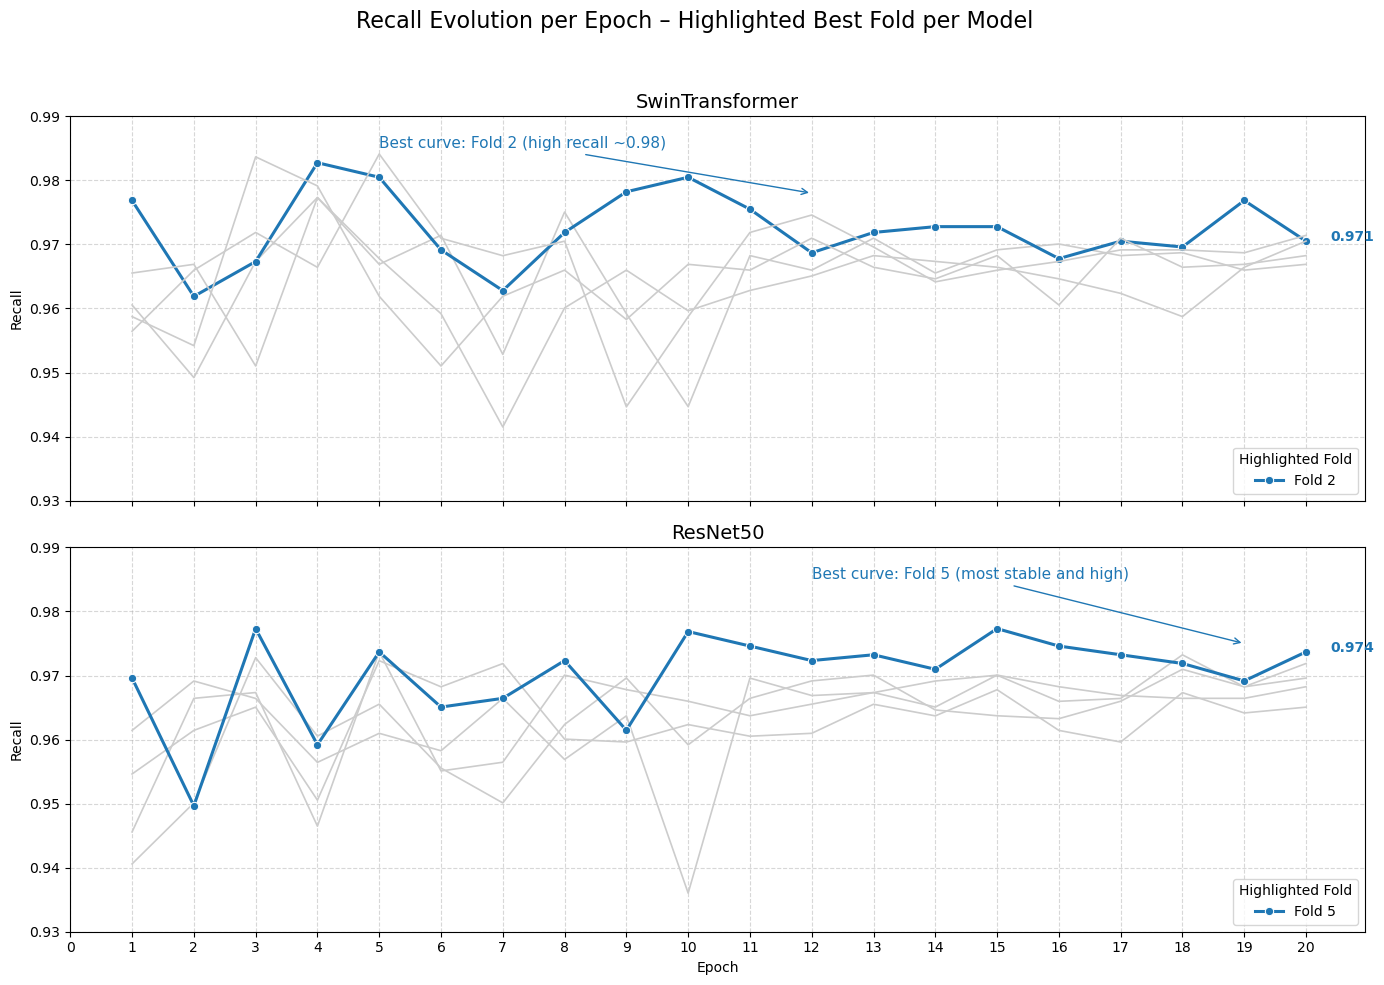

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cores personalizadas
cor_destaque = "#1f77b4"  # azul forte para destaque
cor_pastel = "#cccccc"    # cinza claro para os outros folds

# Remover fold 6
df_filtered = df_all[df_all['fold'] != 6]

# Criar figura com 2 subplots (um em cima do outro)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)

# Loop pelas redes
for idx, rede in enumerate(df_filtered['network'].unique()):
    ax = axes[idx]
    df_rede = df_filtered[df_filtered['network'] == rede]

    # Definir fold de destaque
    fold_destaque = 2 if "Swin" in rede else 5

    # Traçar todas as curvas
    for fold in sorted(df_rede['fold'].unique()):
        df_fold = df_rede[df_rede['fold'] == fold]

        # Escolher cor
        cor = cor_destaque if fold == fold_destaque else cor_pastel

        # Traçar curva
        sns.lineplot(
            data=df_fold,
            x='epoch',
            y='recall',
            label=f"Fold {fold}" if fold == fold_destaque else None,
            color=cor,
            marker='o' if fold == fold_destaque else None,
            linewidth=2.2 if fold == fold_destaque else 1.2,
            ax=ax
        )

        # Adicionar valor final ao final da curva destacada
        if fold == fold_destaque:
            last_point = df_fold[df_fold['epoch'] == df_fold['epoch'].max()]
            recall_final = last_point['recall'].values[0]
            epoch_final = last_point['epoch'].values[0]
            ax.text(epoch_final + 0.4, recall_final, f"{recall_final:.3f}",
                    fontsize=10, fontweight='bold', color=cor)

    # Texto explicativo para a curva destacada
    if "Swin" in rede:
        ax.annotate("Best curve: Fold 2 (high recall ~0.98)", xy=(12, 0.978),
                    xytext=(5, 0.985), arrowprops=dict(arrowstyle="->", color=cor_destaque),
                    fontsize=11, color=cor_destaque)
    else:
        ax.annotate("Best curve: Fold 5 (most stable and high)", xy=(19, 0.975),
                    xytext=(12, 0.985), arrowprops=dict(arrowstyle="->", color=cor_destaque),
                    fontsize=11, color=cor_destaque)

    ax.set_title(f"{rede}", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Recall")
    ax.set_ylim(0.93, 0.99)  # foco nos dados
    ax.set_xticks(range(0, 21))
    ax.set_yticks([0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Highlighted Fold", loc='lower right')

# Título geral
plt.suptitle("Recall Evolution per Epoch – Highlighted Best Fold per Model", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


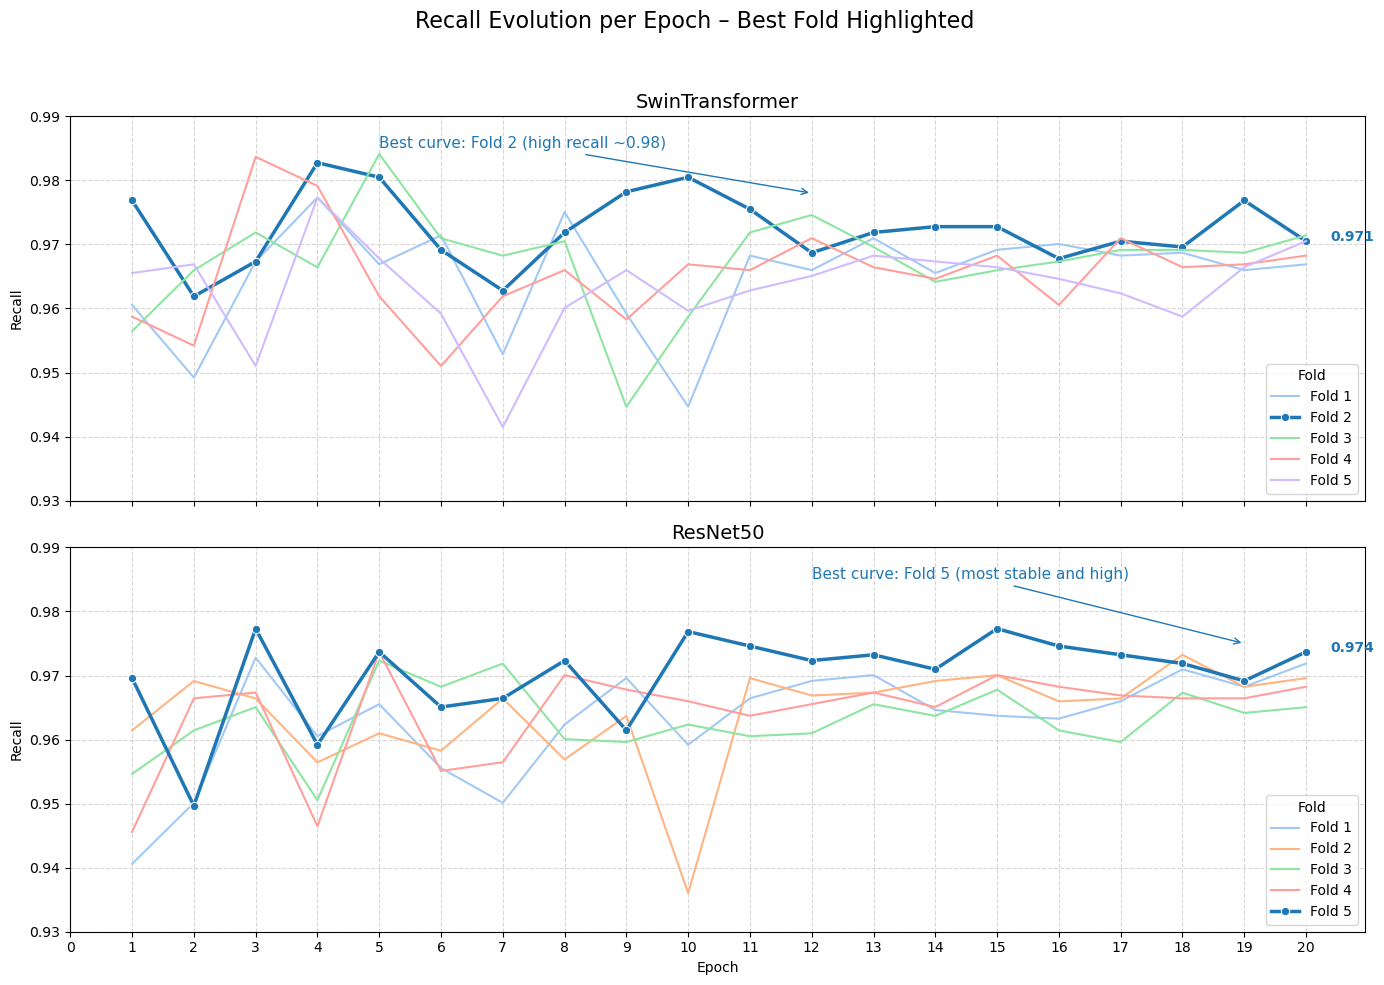

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Paleta pastel para os folds não destacados
cores_base = sns.color_palette("pastel", 5)
cor_destaque = "#1f77b4"  # azul forte

# Remover fold 6
df_filtered = df_all[df_all['fold'] != 6]

# Criar figura com 2 subplots (um em cima do outro)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)

# Loop pelas redes
for idx, rede in enumerate(df_filtered['network'].unique()):
    ax = axes[idx]
    df_rede = df_filtered[df_filtered['network'] == rede]

    # Definir fold de destaque
    fold_destaque = 2 if "Swin" in rede else 5

    # Traçar todas as curvas
    for i, fold in enumerate(sorted(df_rede['fold'].unique())):
        df_fold = df_rede[df_rede['fold'] == fold]

        if fold == fold_destaque:
            cor = cor_destaque
            estilo = 'o'
            largura = 2.5
        else:
            cor = cores_base[i]
            estilo = None
            largura = 1.5

        sns.lineplot(
            data=df_fold,
            x='epoch',
            y='recall',
            label=f"Fold {fold}",
            color=cor,
            marker=estilo,
            linewidth=largura,
            ax=ax
        )

        # Valor final no fold destaque
        if fold == fold_destaque:
            last_point = df_fold[df_fold['epoch'] == df_fold['epoch'].max()]
            recall_final = last_point['recall'].values[0]
            epoch_final = last_point['epoch'].values[0]
            ax.text(epoch_final + 0.4, recall_final, f"{recall_final:.3f}",
                    fontsize=10, fontweight='bold', color=cor)

    # Anotação visual
    if "Swin" in rede:
        ax.annotate("Best curve: Fold 2 (high recall ~0.98)", xy=(12, 0.978),
                    xytext=(5, 0.985), arrowprops=dict(arrowstyle="->", color=cor_destaque),
                    fontsize=11, color=cor_destaque)
    else:
        ax.annotate("Best curve: Fold 5 (most stable and high)", xy=(19, 0.975),
                    xytext=(12, 0.985), arrowprops=dict(arrowstyle="->", color=cor_destaque),
                    fontsize=11, color=cor_destaque)

    ax.set_title(f"{rede}", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Recall")
    ax.set_ylim(0.93, 0.99)
    ax.set_xticks(range(0, 21))
    ax.set_yticks([0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Fold", loc='lower right')

# Título geral
plt.suptitle("Recall Evolution per Epoch – Best Fold Highlighted", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


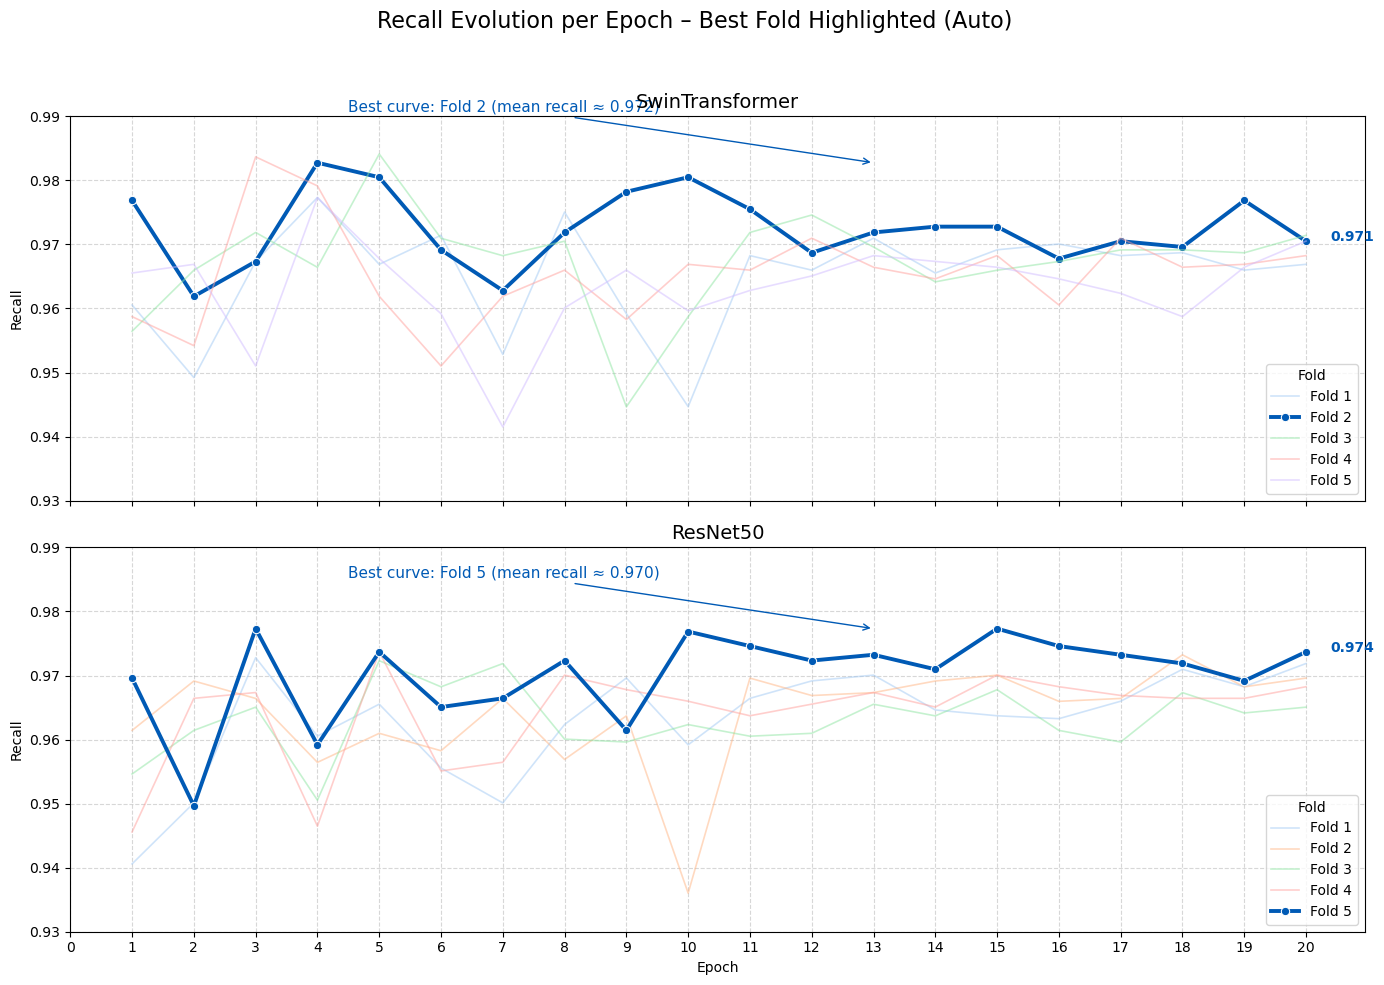

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Paletas de cores
cores_base = sns.color_palette("pastel", 5).as_hex()
cor_destaque = "#005AB5"

# Filtrar apenas folds 1 a 5
df_filtered = df_all[df_all['fold'].astype(int).isin([1, 2, 3, 4, 5])]

# Criar figura com 2 subplots (um por rede)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)

# Loop pelas redes
for idx, rede in enumerate(df_filtered['network'].unique()):
    ax = axes[idx]
    df_rede = df_filtered[df_filtered['network'] == rede]

    # Encontrar o melhor fold pela média de recall
    medias = df_rede.groupby('fold')['recall'].mean()
    fold_destaque = medias.idxmax()
    recall_medio = medias.max()

    for i, fold in enumerate(sorted(df_rede['fold'].astype(int).unique())):
        df_fold = df_rede[df_rede['fold'].astype(int) == fold]

        if fold == fold_destaque:
            cor = cor_destaque
            estilo = 'o'
            largura = 2.8
            alfa = 1.0
        else:
            cor = cores_base[i]
            estilo = None
            largura = 1.2
            alfa = 0.5

        sns.lineplot(
            data=df_fold,
            x='epoch',
            y='recall',
            label=f"Fold {fold}",
            color=cor,
            marker=estilo,
            linewidth=largura,
            alpha=alfa,
            ax=ax
        )

        if fold == fold_destaque:
            last_point = df_fold[df_fold['epoch'] == df_fold['epoch'].max()]
            recall_final = last_point['recall'].values[0]
            epoch_final = last_point['epoch'].values[0]
            ax.text(epoch_final + 0.4, recall_final, f"{recall_final:.3f}",
                    fontsize=10, fontweight='bold', color=cor)

    # Anotação dinâmica
    texto_anotacao = f"Best curve: Fold {fold_destaque} (mean recall ≈ {recall_medio:.3f})"
    pos_y = df_rede[df_rede['fold'] == fold_destaque]['recall'].max()
    ax.annotate(
        texto_anotacao,
        xy=(13, pos_y),
        xytext=(4.5, pos_y + 0.008),
        arrowprops=dict(arrowstyle="->", color=cor_destaque),
        fontsize=11,
        color=cor_destaque
    )

    ax.set_title(f"{rede}", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Recall")
    ax.set_ylim(0.93, 0.99)
    ax.set_xticks(range(0, 21))
    ax.set_yticks([0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Fold", loc='lower right')

# Título geral
plt.suptitle("Recall Evolution per Epoch – Best Fold Highlighted (Auto)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Swin sem optuna e com optuna

In [16]:
df_optuna_swin.head()

,fold,epoch,model,loss,accuracy,precision,recall,f1_score,true_positives,false_positives,true_negatives,false_negatives,learning_rate,network
0,1,1,SwinTransformer_Fold1,0.144427,96.643991,0.968992,0.963719,0.966348,2125,68,2137,80,0.0001,SwinTransformerOptuna
1,1,2,SwinTransformer_Fold1,0.098541,96.213152,0.946147,0.980045,0.962798,2161,123,2082,44,0.0001,SwinTransformerOptuna
2,1,3,SwinTransformer_Fold1,0.083698,96.938776,0.962466,0.976871,0.969615,2154,84,2121,51,0.0001,SwinTransformerOptuna
3,1,4,SwinTransformer_Fold1,0.072330,96.938776,0.973901,0.964626,0.969241,2127,57,2148,78,0.0001,SwinTransformerOptuna
4,1,5,SwinTransformer_Fold1,0.057460,96.848073,0.976037,0.960544,0.968229,2118,52,2153,87,0.0001,SwinTransformerOptuna


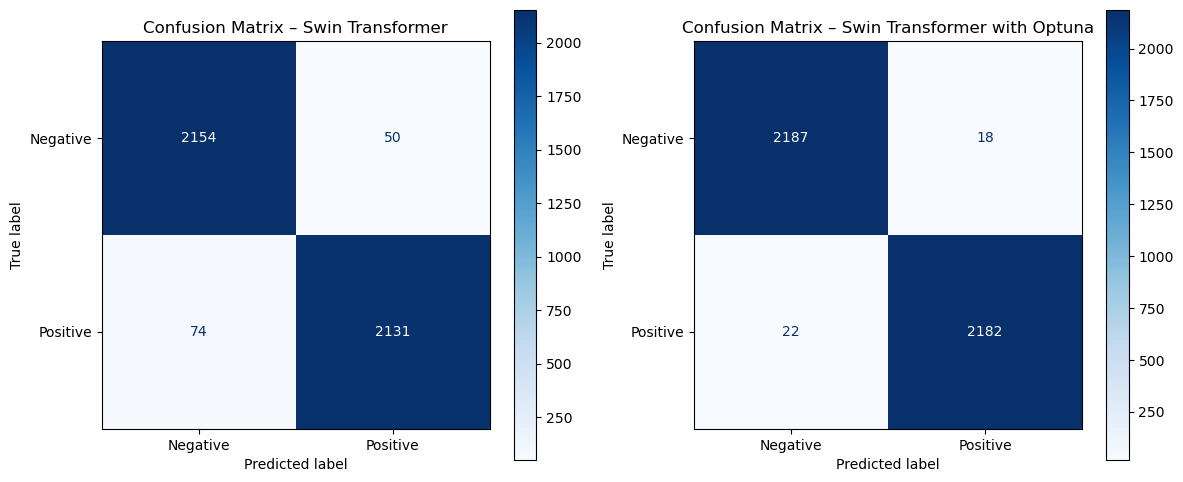

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Dados do melhor modelo Swin
best_swin = df_swin.loc[df_swin['loss'].idxmin()]
cm_swin = confusion_matrix(
    [1]*int(best_swin['true_positives']) + [1]*int(best_swin['false_negatives']) +
    [0]*int(best_swin['true_negatives']) + [0]*int(best_swin['false_positives']),
    
    [1]*int(best_swin['true_positives']) + [0]*int(best_swin['false_negatives']) +
    [0]*int(best_swin['true_negatives']) + [1]*int(best_swin['false_positives'])
)

# Dados do melhor modelo Swin com Optuna
best_opt_swin = df_optuna_swin.loc[df_optuna_swin['loss'].idxmin()]
cm_opt_swin = confusion_matrix(
    [1]*int(best_opt_swin['true_positives']) + [1]*int(best_opt_swin['false_negatives']) +
    [0]*int(best_opt_swin['true_negatives']) + [0]*int(best_opt_swin['false_positives']),
    
    [1]*int(best_opt_swin['true_positives']) + [0]*int(best_opt_swin['false_negatives']) +
    [0]*int(best_opt_swin['true_negatives']) + [1]*int(best_opt_swin['false_positives'])
)

# Plot lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Swin
disp_swin = ConfusionMatrixDisplay(cm_swin, display_labels=["Negative", "Positive"])
disp_swin.plot(ax=axes[0], cmap="Blues", values_format='d')
axes[0].set_title("Confusion Matrix – Swin Transformer")

# ResNet
disp_opt_swin = ConfusionMatrixDisplay(cm_opt_swin, display_labels=["Negative", "Positive"])
disp_opt_swin.plot(ax=axes[1], cmap="Blues", values_format='d')
axes[1].set_title("Confusion Matrix – Swin Transformer with Optuna")

# Remover títulos automáticos duplicados nos eixos
for ax in axes:
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()


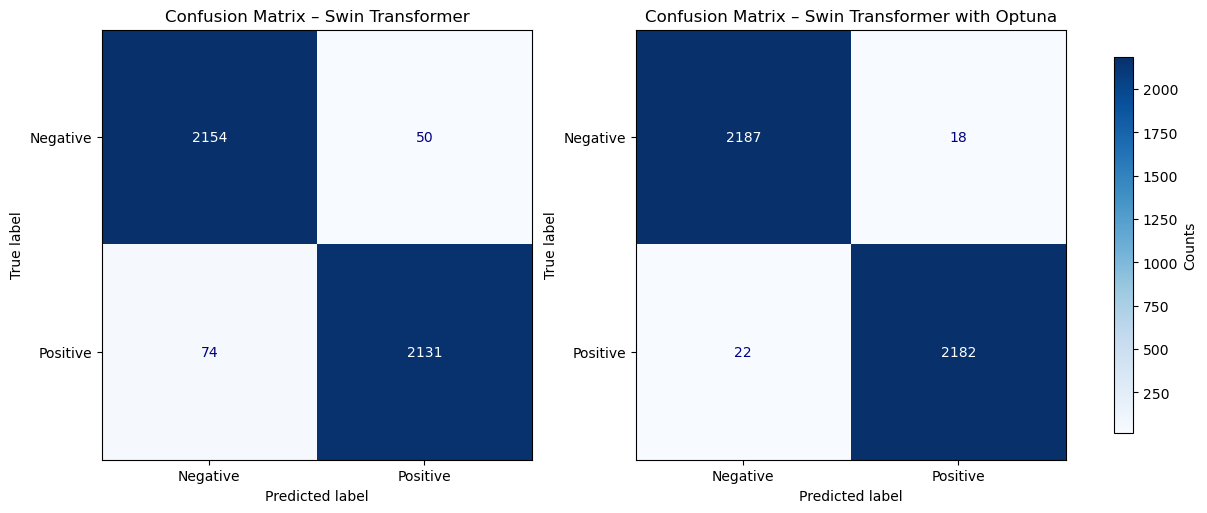

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_conf_matrix(cm, title, ax, cmap="Blues"):
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Negative", "Positive"])
    ax.set_yticklabels(["Negative", "Positive"])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    # Contraste dinâmico: branco para fundo escuro, navy para fundo claro
    thresh = cm.max() / 2
    for i, j in np.ndindex(cm.shape):
        color = "white" if cm[i, j] > thresh else "navy"
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', color=color)

    return im

# Plot com colorbar única à direita
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

im1 = plot_conf_matrix(cm_swin, "Confusion Matrix – Swin Transformer", axes[0])
im2 = plot_conf_matrix(cm_opt_swin, "Confusion Matrix – Swin Transformer with Optuna", axes[1])

# Adiciona colorbar na lateral direita
cbar = fig.colorbar(im2, ax=axes, location='right', shrink=0.85)
cbar.set_label("Counts")

plt.show()


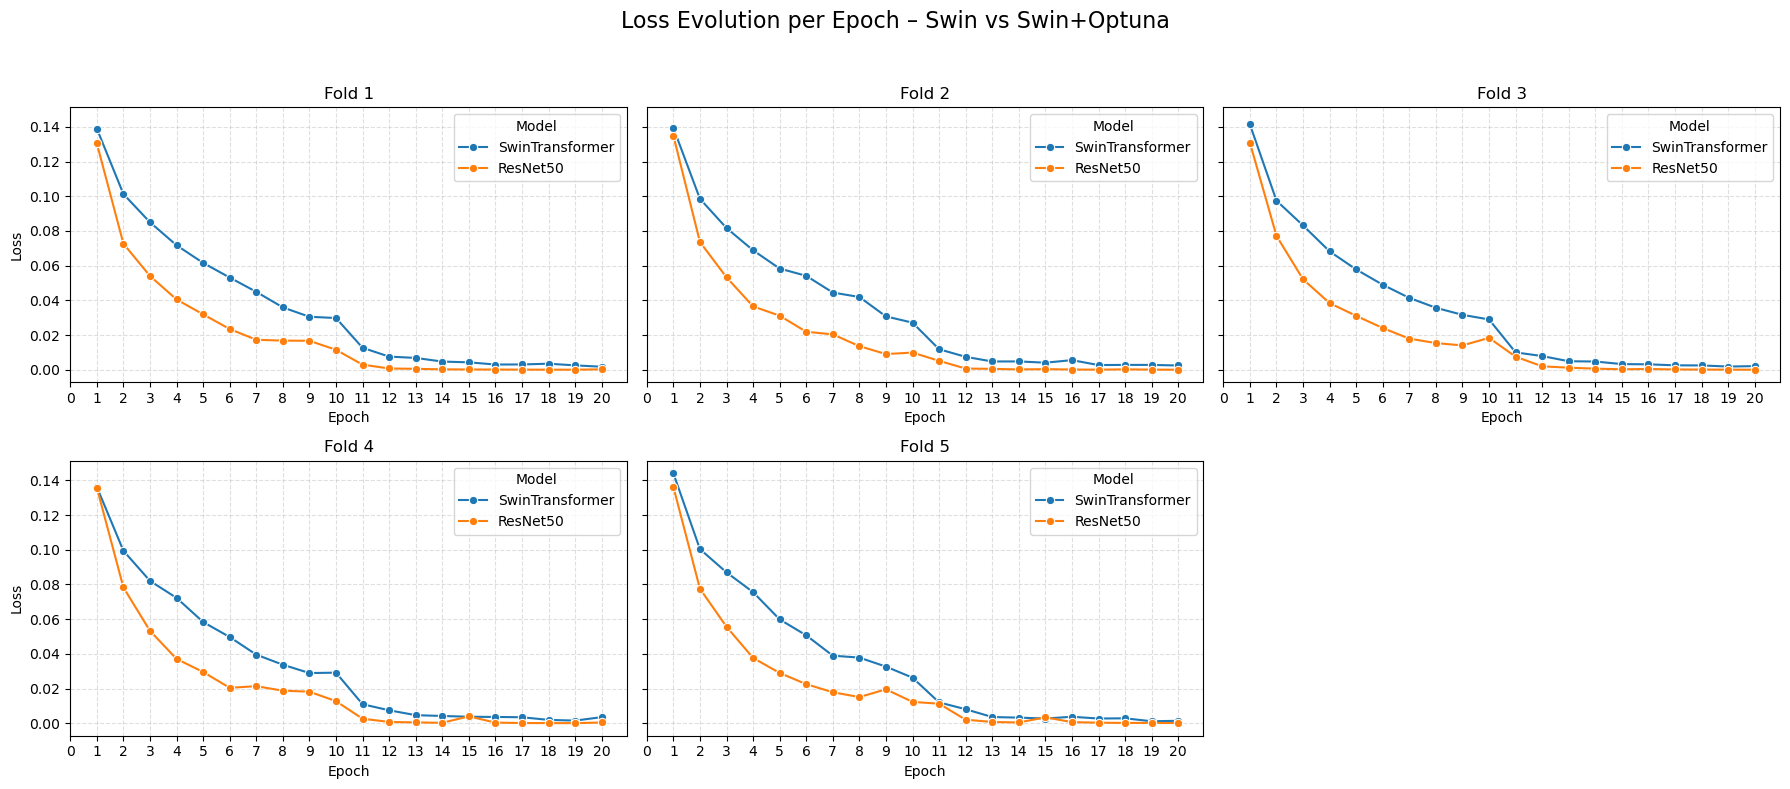

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Adiciona coluna de identificação
df_swin['network'] = 'SwinTransformer'
df_optuna_swin['network'] = 'SwinTransformer+Optuna'
df_all_swin = pd.concat([df_swin, df_optuna_swin], ignore_index=True)

# Junta os dois DataFrames
df_all_swin['fold'] = df_all_swin['fold'].astype(int)  # primeiro transforma em inteiro
df_all_swin = df_all_swin[df_all_swin['fold'] != 6]         # depois remove o fold 6 corretamente


# Garante que 'fold' seja tratado como número
df_all_swin['fold'] = df_all_swin['fold'].astype(int)
folds = sorted(df_all_swin['fold'].unique())

# Cria subplots 2x3
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
axes = axes.flatten()

# Gráfico por fold
for i, fold in enumerate(folds):
    ax = axes[i]
    sns.lineplot(
        data=df_all[df_all['fold'] == fold],
        x='epoch',
        y='loss',
        hue='network',
        marker='o',
        errorbar=None,
        ax=ax
    )
    ax.set_title(f"Fold {fold}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_xticks(range(0, 21))
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(title='Model', loc='best')

# Esconde slot vazio
if len(folds) < 6:
    axes[-1].axis('off')

# Título geral
plt.suptitle("Loss Evolution per Epoch – Swin vs Swin+Optuna", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


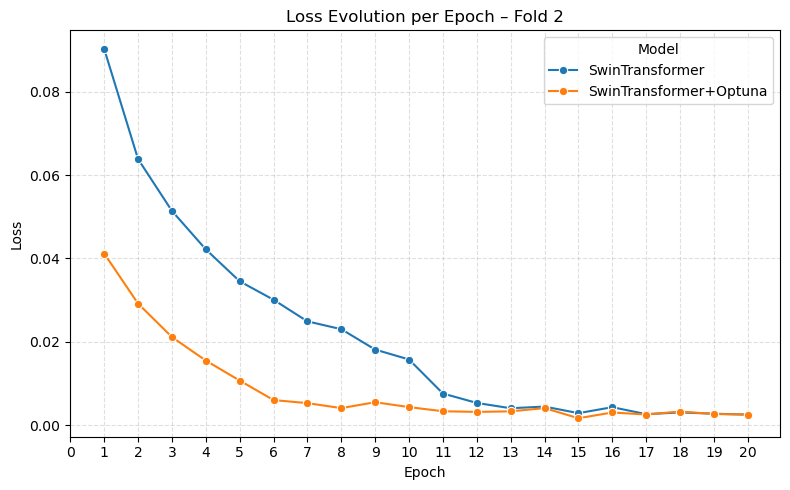

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Adiciona coluna de identificação
df_swin['network'] = 'SwinTransformer'
df_optuna_swin['network'] = 'SwinTransformer+Optuna'
df_all_swin = pd.concat([df_swin, df_optuna_swin], ignore_index=True)

# Garante que 'fold' seja tratado como número e filtra apenas o Fold 2
df_all_swin['fold'] = df_all_swin['fold'].astype(int)
df_fold2 = df_all_swin[df_all_swin['fold'] == 2]

# Plot único para o Fold 2
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_fold2,
    x='epoch',
    y='loss',
    hue='network',
    marker='o',
    errorbar=None
)
plt.title("Loss Evolution per Epoch – Fold 2")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(0, 21))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Model', loc='best')
plt.tight_layout()
plt.show()


In [21]:

# Adiciona a coluna "network" em cada DataFrame, se ainda não tiver feito
df_swin['network'] = 'SwinTransformer'
df_optuna_swin['network'] = 'SwinTransformer+Optuna'

# Junta os dois em um único DataFrame
df_all_swin = pd.concat([df_swin, df_optuna_swin], ignore_index=True)

# Garante os tipos corretos
df_all_swin['fold'] = df_all_swin['fold'].astype(int)
df_all_swin['epoch'] = df_all_swin['epoch'].astype(int)
df_all_swin['recall'] = df_all_swin['recall'].astype(float)


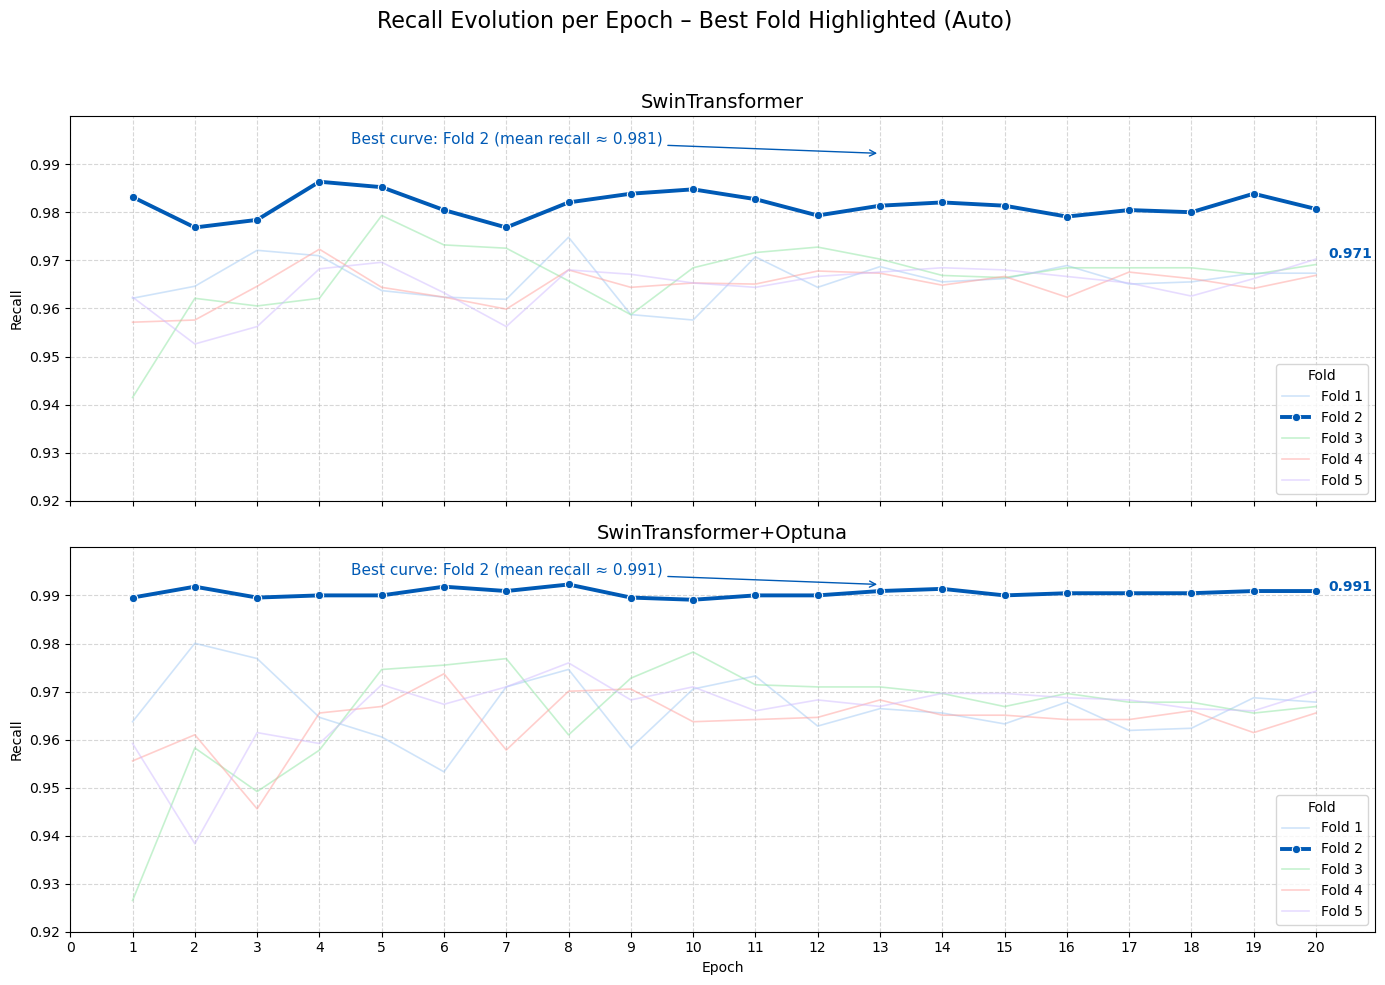

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Paletas de cores
cores_base = sns.color_palette("pastel", 5).as_hex()
cor_destaque = "#005AB5"

# Filtrar apenas folds 1 a 5
df_filtered = df_all_swin[df_all_swin['fold'].astype(int).isin([1, 2, 3, 4, 5])]

# Criar figura com 2 subplots (um por rede)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)

# Loop pelas redes
for idx, rede in enumerate(df_filtered['network'].unique()):
    ax = axes[idx]
    df_rede = df_filtered[df_filtered['network'] == rede]

    # Encontrar o melhor fold pela média de recall
    medias = df_rede.groupby('fold')['recall'].mean()
    fold_destaque = medias.idxmax()
    recall_medio = medias.max()

    for i, fold in enumerate(sorted(df_rede['fold'].astype(int).unique())):
        df_fold = df_rede[df_rede['fold'].astype(int) == fold]

        if fold == fold_destaque:
            cor = cor_destaque
            estilo = 'o'
            largura = 2.8
            alfa = 1.0
        else:
            cor = cores_base[i]
            estilo = None
            largura = 1.2
            alfa = 0.5

        sns.lineplot(
            data=df_fold,
            x='epoch',
            y='recall',
            label=f"Fold {fold}",
            color=cor,
            marker=estilo,
            linewidth=largura,
            alpha=alfa,
            errorbar=None,
            ax=ax
        )

        if fold == fold_destaque:
            last_point = df_fold[df_fold['epoch'] == df_fold['epoch'].max()]
            recall_final = last_point['recall'].values[0]
            epoch_final = last_point['epoch'].values[0]
            ax.text(epoch_final + 0.2, recall_final, f"{recall_final:.3f}",
                    fontsize=10, fontweight='bold', color=cor)

    # Anotação dinâmica
    texto_anotacao = f"Best curve: Fold {fold_destaque} (mean recall ≈ {recall_medio:.3f})"
    pos_y = df_rede[df_rede['fold'] == fold_destaque]['recall'].max()
    ax.annotate(
        texto_anotacao,
        xy=(13, pos_y),
        xytext=(4.5, pos_y + 0.002),
        arrowprops=dict(arrowstyle="->", color=cor_destaque),
        fontsize=11,
        color=cor_destaque
    )

    ax.set_title(f"{rede}", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Recall")
    ax.set_ylim(0.92, 1)
    ax.set_xticks(range(0, 21))
    ax.set_yticks([0.92,0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Fold", loc='lower right')

# Título geral
plt.suptitle("Recall Evolution per Epoch – Best Fold Highlighted (Auto)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


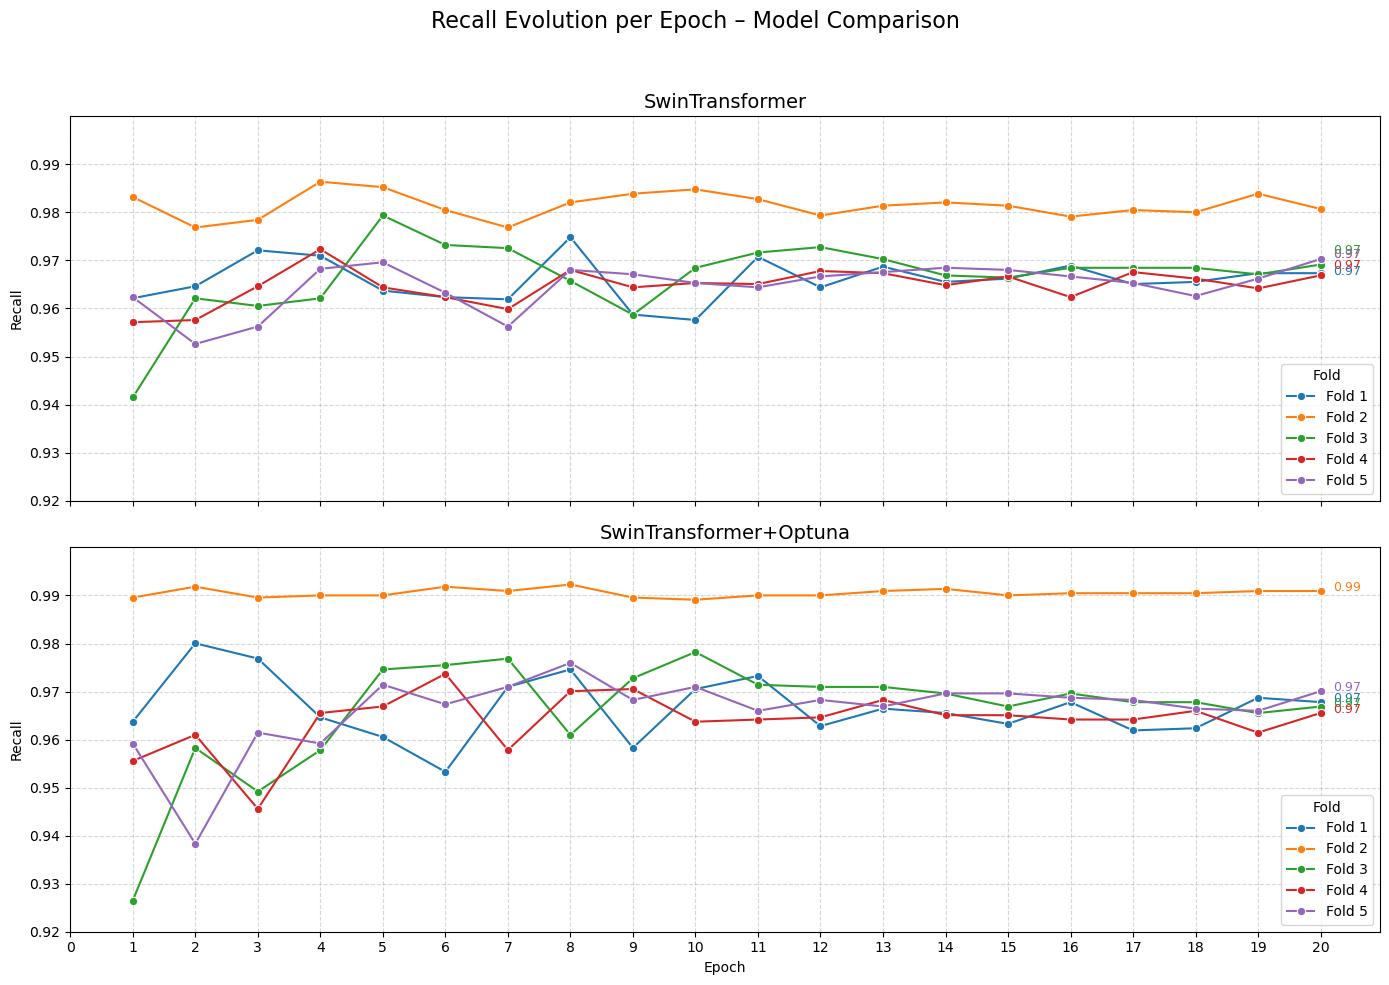

In [23]:

# Paleta de cores para até 5 folds
cores_folds = sns.color_palette("tab10", 5)

# Filtra apenas folds 1 a 5
df_filtered = df_all_swin[df_all_swin['fold'].isin([1, 2, 3, 4, 5])]

# Cria figura com 2 subplots (um por rede)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, sharey=True)

# Loop pelas redes
for idx, rede in enumerate(df_filtered['network'].unique()):
    ax = axes[idx]
    df_rede = df_filtered[df_filtered['network'] == rede]

    # Traça uma linha por fold
    for i, fold in enumerate(sorted(df_rede['fold'].unique())):
        df_fold = df_rede[df_rede['fold'] == fold]
        sns.lineplot(
            data=df_fold,
            x='epoch',
            y='recall',
            label=f"Fold {fold}",
            color=cores_folds[i],
            marker='o',
            errorbar=None,
            ax=ax
        )

        # Texto no último ponto da curva
        last_point = df_fold[df_fold['epoch'] == df_fold['epoch'].max()]
        recall_final = last_point['recall'].values[0]
        epoch_final = last_point['epoch'].values[0]
        ax.text(epoch_final + 0.2, recall_final, f"{recall_final:.2f}", fontsize=9, color=cores_folds[i])

    ax.set_title(f"{rede}", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Recall")
    ax.set_ylim(0.92, 1)
    ax.set_xticks(range(0, 21))
    ax.set_yticks([0.92,0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Fold", loc='lower right')

# Título geral
plt.suptitle("Recall Evolution per Epoch – Model Comparison", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
